# Unsupervised Learning Project
## Task 3 - Evaluation Protocol

**Team (G4-P2):** José Nunes (73137) · João Lourenço (72904) · Leonor Afonso (73491)

**Course:** Unsupervised Learning · 2025/2026 · NOVA FCT, Departamento de Informática

---

**Task 3 Overview:** 

Task 3 brings together the three clustering methods produced in Tasks 1 and 2 
(**K-Means**, **iK-Means**, and **Ward Hierarchical Clustering**) into a single, 
unified evaluation framework. While Tasks 1 and 2 each performed partial stability 
checks on their respective methods, Task 3 executes the full evaluation protocol 
defined in the project brief:

- **Internal validity indices** (Silhouette, Calinski–Harabasz, Davies–Bouldin) 
  reported in a single consolidated comparison table across all three methods.
- **Stability analysis** with ≥ 5 seeds/resamples per method, reporting mean ± std 
  of indices and mean pairwise ARI.
- **One controlled preprocessing variant** (R1: RobustScaler vs StandardScaler), 
  testing whether cluster structure is sensitive to outlier influence.
- **Cross-method agreement** (ARI between K-Means, iK-Means, and Ward at their 
  respective best k), providing convergent or divergent evidence on the 
  segmentation structure.

All indices are computed in the same Euclidean space on representation R0, 
consistent with the metric governance established in Tasks 1 and 2. 


## 1. Environment, Imports and Reproducibility

In [ ]:
#Imports
import os
import time
import warnings
import json
import hashlib
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from dataclasses import dataclass
from numpy.typing import NDArray
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)

#Reproducibility 
SEEDS_STABILITY= [12345, 23456, 34567, 45678, 56789, 67890, 78901, 89012, 90123, 11111] #5 seeds for stability analysis
SUBSAMPLE_N = 10_000
SEED = 12345
np.random.seed(SEED)

#Project layout
def _find_project_root(markers=('requirements.txt', '.git', 'environment.yml')):
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate
    return here

PROJECT_ROOT = _find_project_root()
DATA_DIR     = PROJECT_ROOT / 'data' / 'raw'
RESULTS_DIR  = PROJECT_ROOT / 'results'
FIG_DIR      = RESULTS_DIR / 'figures'
TBL_DIR      = RESULTS_DIR / 'tables'
RPT_DIR      = RESULTS_DIR / 'reports'

for d in (FIG_DIR, TBL_DIR, RPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

#Plot defaults
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})
sns.set_style('whitegrid')

REPRESENTATION_ID = 'R0-standard-noADR-marketSegment-countryRare1pct'

print("Environment ready.")
print(f"Project root         : {PROJECT_ROOT}")
print(f"Master seed          : {SEED}")
print(f"Stability seeds      : {SEEDS_STABILITY}")
print(f"Silhouette subsample : {SUBSAMPLE_N:,}")

Environment ready.
Project root         : /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking
Master seed          : 12345
Stability seeds      : [12345, 23456, 34567, 45678, 56789]
Silhouette subsample : 10,000


## 2. Reproduce Task nº1 and Task nº2

This notebook is therefore self-contained: it re-executes the preprocessing pipeline and the three models using their best k values in order to ensure that X_R0 and the labels are identical to those produced in the previous tasks.

In [ ]:
#REPRESENTATION CHOICE: R0 follows Task 1 exactly: StandardScaler on all numerical features, NO log transforms.
#REPRESENTATION_ID = 'R0-standard-noLog-noADR-marketSegment-countryRare1pct'
#Task 3 is the same model produced in Task 1.

#Load dataset
DATASET_PATH = DATA_DIR / 'hotel_bookings.csv'

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}. "
        "Place hotel_bookings.csv in data/raw/ before running."
    )

with open(DATASET_PATH, 'rb') as f:
    DATASET_MD5 = hashlib.md5(f.read()).hexdigest()

df_raw = pd.read_csv(DATASET_PATH)
print(f"Dataset MD5       : {DATASET_MD5}")
print(f"Raw dataset shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

#Sub-population filter: TA/TO only (identical to Task 1)
df = df_raw[df_raw['distribution_channel'] == 'TA/TO'].copy()
print(f"TA/TO records     : {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% of raw)")

# Feature engineering (identical to Task 1)
df['total_nights']  = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['party_size']    = df['adults'] + df['children'].fillna(0) + df['babies']
df['weekend_share'] = np.where(
    df['total_nights'] > 0,
    df['stays_in_weekend_nights'] / df['total_nights'],
    0.0
)

# Data cleaning (identical to Task 1) 
# Drop bookings with no guests — invalid behavioural unit (Task 1 §Data Cleaning)
df = df[df['party_size'] > 0].copy()
print(f"After dropping party_size==0 : {len(df):,}")

# Impute missings (Task 1: country→PRT per reference paper; 4 NaN children→0)
df['country']       = df['country'].fillna('PRT')
df['children']      = df['children'].fillna(0)
df['party_size']    = df['adults'] + df['children'] + df['babies']   # recompute
df['total_nights']  = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['weekend_share'] = np.where(
    df['total_nights'] > 0,
    df['stays_in_weekend_nights'] / df['total_nights'],
    0.0
)

# ADR-clean subset for post-hoc profiling only — NOT used to form clusters
df_adr_clean = df[(df['adr'] > 0) & (df['adr'] <= 1000)].copy()
print(f"Final MAIN sub-population (R0) : {len(df):,}")

# Conservative outlier caps (identical to Task 1)
# Applied before the pipeline so that StandardScaler is not pulled by extreme
# tails. Caps are conservative (P99 for count variables, domain ceiling for
# parking and special requests). Task 1 §Main Representation R0 documents these.
df['previous_cancellations']         = df['previous_cancellations'].clip(
    upper=df['previous_cancellations'].quantile(0.99))
df['previous_bookings_not_canceled'] = df['previous_bookings_not_canceled'].clip(
    upper=df['previous_bookings_not_canceled'].quantile(0.99))
df['required_car_parking_spaces']    = df['required_car_parking_spaces'].clip(upper=3)
df['total_of_special_requests']      = df['total_of_special_requests'].clip(upper=5)

# Rare-category grouping (1 % threshold, identical to Task 1)
RARE_THRESHOLD = 0.01
cat_inputs = ['market_segment', 'reserved_room_type', 'meal',
              'customer_type', 'deposit_type', 'country', 'arrival_date_month']

print(f"\nRare-category grouping (< {RARE_THRESHOLD*100:.0f}% threshold):")
for col in cat_inputs:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < RARE_THRESHOLD].index.tolist()
    if rare:
        df[col] = df[col].where(~df[col].isin(rare), other='Other')
        df_adr_clean[col] = df_adr_clean[col].where(
            ~df_adr_clean[col].isin(rare), other='Other')
        print(f"  {col:25s}: grouped {len(rare):>3d} levels → 'Other'")
    else:
        print(f"  {col:25s}: no rare categories")

# Feature sets — R0 definition (identical to Task 1)
NUM_FEATURES_NUM = ['lead_time',
                    'previous_cancellations', 'previous_bookings_not_canceled',
                    'total_nights', 'weekend_share', 'party_size',
                    'required_car_parking_spaces', 'total_of_special_requests']
NUM_FEATURES_BIN = ['is_repeated_guest']   # binary {0,1} — not re-scaled (mirrors OHE block)
CAT_FEATURES     = ['market_segment', 'reserved_room_type', 'meal',
                    'customer_type', 'deposit_type', 'country', 'arrival_date_month']
ALL_NUM          = NUM_FEATURES_NUM + NUM_FEATURES_BIN

# Profiling-only — excluded from clustering, used post-hoc only (leakage control)
POSTHOC_VARS = ['is_canceled', 'reservation_status', 'hotel',
                'booking_changes', 'adr', 'assigned_room_type']

print(f"\nFinal clustering inputs (R0 — no log):")
print(f"  numerical (StandardScaler) : {NUM_FEATURES_NUM}")
print(f"  binary    (unscaled)       : {NUM_FEATURES_BIN}")
print(f"  categorical (one-hot)      : {CAT_FEATURES}")
print(f"\nPost-hoc / profiling-only   : {POSTHOC_VARS}")

# Preprocessing pipeline R0 (identical to Task 1)
# Metric sentence (R0): Euclidean distance on the final encoded matrix X_R0, which stacks StandardScaler-scaled numerical variables
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
numeric_bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # NO scaler: keeps 0/1, mirrors the one-hot block (Task 1 rationale)
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_R0 = ColumnTransformer(
    transformers=[
        ('num',     numeric_pipe,     NUM_FEATURES_NUM),
        ('num_bin', numeric_bin_pipe, NUM_FEATURES_BIN),
        ('cat',     cat_pipe,         CAT_FEATURES),
    ],
    remainder='drop',
)

t0     = time.time()
X_R0   = preprocessor_R0.fit_transform(df)
t_prep = time.time() - t0

# Build human-readable feature names (useful for profiling and diagnostics)
ohe       = preprocessor_R0.named_transformers_['cat']['onehot']
cat_names = ohe.get_feature_names_out(CAT_FEATURES).tolist()
feature_names_R0 = NUM_FEATURES_NUM + NUM_FEATURES_BIN + cat_names

# Canonical representation identifier — must match Task 1 exactly
REPRESENTATION_ID = 'R0-standard-noLog-noADR-marketSegment-countryRare1pct'

print(f"\nPreprocessing completed in {t_prep:.2f}s")
print(f"R0 matrix shape   : {X_R0.shape[0]:,} rows × {X_R0.shape[1]} features")
print(f"  ({len(NUM_FEATURES_NUM)} numerical + {len(NUM_FEATURES_BIN)} binary"
      f" + {len(cat_names)} one-hot)")
print(f"Representation ID : {REPRESENTATION_ID}")

Dataset MD5       : 5bf588c5a949443e021fb7c847d31b27
Raw dataset shape : 119,390 rows × 32 columns
TA/TO records     : 97,870  (82.0% of raw)
After dropping party_size==0 : 97,750
Final MAIN sub-population (R0) : 97,750

Rare-category grouping (< 1% threshold):
  market_segment           : grouped   4 levels → 'Other'
  reserved_room_type       : grouped   3 levels → 'Other'
  meal                     : grouped   2 levels → 'Other'
  customer_type            : grouped   1 levels → 'Other'
  deposit_type             : grouped   1 levels → 'Other'
  country                  : grouped 160 levels → 'Other'
  arrival_date_month       : no rare categories

Final clustering inputs (R0 — no log):
  numerical (StandardScaler) : ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled', 'total_nights', 'weekend_share', 'party_size', 'required_car_parking_spaces', 'total_of_special_requests']
  binary    (unscaled)       : ['is_repeated_guest']
  categorical (one-hot)      : ['mark

### Reproduce the models to best k

In [82]:
# iK-Means: Anomalous Pattern implementation (Mirkin) 
# The full specification-compliant implementation is copied verbatim from Task 1 so that this notebook is self-contained

FloatArray = NDArray[np.float64]

@dataclass(frozen=True)
class APCluster:
    """One anomalous-pattern cluster as defined in the iK-Means specification."""
    indices:       list          # row indices of the working matrix X (sorted)
    centroid_raw:  FloatArray
    centroid_std:  FloatArray
    size:          int
    scatter_pct:   float

def compute_feature_statistics(
    X: FloatArray,
    use_unit_ranges: bool = False,
) -> tuple[FloatArray, FloatArray, float]:
    """Return (mean, scales, total_scatter) per the iK-Means specification.

    scales is the per-feature range r_j = max - min, with r_j ← 1 where r_j == 0.
    use_unit_ranges=True forces r_j == 1 (unit-test helper).
    """
    X = np.ascontiguousarray(X, dtype=np.float64)
    mu = X.mean(axis=0)
    if use_unit_ranges:
        r = np.ones(X.shape[1], dtype=np.float64)
    else:
        r = X.max(axis=0) - X.min(axis=0)
        r = np.where(r == 0, 1.0, r)
    Y = (X - mu) / r
    D = float((Y * Y).sum())
    return mu, r, D

def normalized_squared_distances(
    X: FloatArray,
    indices: list,
    scales: FloatArray,
    reference: FloatArray,
) -> FloatArray:
    """δ_r(x_i, p) for every i in indices (specification definition)."""
    Xi   = X[indices]
    diff = (Xi - reference) / scales
    return (diff * diff).sum(axis=1)

def cluster_centroid(X: FloatArray, indices: list) -> FloatArray:
    """Component-wise mean of X[indices]."""
    return X[indices].mean(axis=0)

def separate_cluster(
    X: FloatArray,
    indices: list,
    scales: FloatArray,
    a: FloatArray,
    b: FloatArray,
) -> list:
    """Return rows i in indices STRICTLY closer to a than to b under δ_r.
    Ties stay with b (the reference/grand-mean) per the specification.
    """
    Xi     = X[indices]
    diff_a = (Xi - a) / scales
    diff_b = (Xi - b) / scales
    d_a    = (diff_a * diff_a).sum(axis=1)
    d_b    = (diff_b * diff_b).sum(axis=1)
    mask   = d_a < d_b                          # strict inequality
    return np.asarray(indices)[mask].tolist()

def extract_anomalous_cluster(
    X: FloatArray,
    indices: list,
    scales: FloatArray,
    mean: FloatArray,
    initial_centroid: FloatArray,
    seed_index: int,
    tol: float   = 1e-12,
    max_iter: int = 10_000,
) -> tuple[list, FloatArray]:
    """One AP extraction (specification Algorithm 2). Returns (S, centroid).

    Inner-loop stop criteria (whichever fires first):
      1. Membership stability: S_t == S_{t-1}  (exact convergence condition).
      2. Centroid stability  : ||c_new - c_old||_2 <= tol  (numerical safeguard).
      3. Hard cap            : max_iter iterations.
    """
    c      = np.asarray(initial_centroid, dtype=np.float64).copy()
    S_prev = None
    for _ in range(max_iter):
        S = separate_cluster(X, indices, scales, a=c, b=mean)
        if len(S) == 0:
            S = [seed_index]              # numerical safeguard: keep at least the seed
        c_new  = cluster_centroid(X, S)
        S_arr  = np.asarray(S)
        if (S_prev is not None
                and S_arr.shape == S_prev.shape
                and np.array_equal(S_arr, S_prev)):
            return sorted(S), c_new       # membership stabilised
        if np.linalg.norm(c_new - c) <= tol:
            return sorted(S), c_new       # centroid stabilised
        c      = c_new
        S_prev = S_arr
    return sorted(S), c                   # max_iter reached


def ikmeans_initialize(
    X: FloatArray,
    min_cluster_size: int,
    tol: float   = 1e-12,
    max_iter: int = 10_000,
    use_unit_ranges: bool = False,
) -> tuple[list, FloatArray]:
    """Full iK-Means initialisation (specification Algorithm 1).

    Outer-loop stop criterion: residual set is empty (every record assigned).
    Returns (ap_clusters, init_centroids) where init_centroids are the
    STANDARDISED centroids of clusters that pass the min_cluster_size filter.
    """
    X  = np.ascontiguousarray(X, dtype=np.float64)
    mu, r, D = compute_feature_statistics(X, use_unit_ranges=use_unit_ranges)

    n             = X.shape[0]
    remains_mask  = np.ones(n, dtype=bool)
    Y             = (X - mu) / r
    d_to_mu_full  = (Y * Y).sum(axis=1)   # pre-computed; does not change

    ap_clusters: list[APCluster] = []

    while remains_mask.any():
        # Pick seed: entity farthest from grand mean in the residual set
        d_remains  = np.where(remains_mask, d_to_mu_full, -np.inf)
        seed_index = int(np.argmax(d_remains))
        seed       = X[seed_index].copy()

        remains_idx = np.where(remains_mask)[0].tolist()
        S, c = extract_anomalous_cluster(
            X=X, indices=remains_idx, scales=r, mean=mu,
            initial_centroid=seed, seed_index=seed_index,
            tol=tol, max_iter=max_iter,
        )
        z           = (c - mu) / r
        scatter_pct = (100.0 * len(S) * float((z * z).sum()) / D
                       if D > 0 else 0.0)

        ap_clusters.append(APCluster(
            indices=sorted(S), centroid_raw=c, centroid_std=z,
            size=len(S), scatter_pct=scatter_pct,
        ))
        remains_mask[np.asarray(S)] = False   # remove assigned rows

    retained = [rec for rec in ap_clusters if rec.size >= min_cluster_size]
    if not retained:
        raise ValueError(
            f"No AP cluster satisfies min_cluster_size={min_cluster_size}; "
            f"largest has size {max(rec.size for rec in ap_clusters)}."
        )
    init_centroids = np.vstack([rec.centroid_std for rec in retained])
    return ap_clusters, init_centroids


# Quick self-test on synthetic 3-cluster data (copied from Task 1)
def _self_test_ikmeans() -> tuple[int, int]:
    rng = np.random.default_rng(0)
    Xs  = np.vstack([
        rng.normal(loc=[0, 0], scale=0.2, size=(200, 2)),
        rng.normal(loc=[5, 5], scale=0.2, size=(200, 2)),
        rng.normal(loc=[5, 0], scale=0.2, size=(200, 2)),
    ])
    ap_list, init = ikmeans_initialize(Xs, min_cluster_size=20)
    assert init.shape[1] == 2
    assert init.shape[0] >= 3, "Should retain ≥ 3 AP seeds on this 3-cluster data."
    return len(ap_list), init.shape[0]

n_total_ap, n_retained = _self_test_ikmeans()
print(f"iK-Means self-test: {n_retained} retained AP seeds out of "
      f"{n_total_ap} extracted — OK.")

# Hyper-parameters for iK-Means (identical to Task 1) 
IK_AP_SAMPLE_N      = 20_000   
IK_MIN_CLUSTER_SIZE = 50     


# Best-k values (hardcoded from Task 1 / Task 2 selection rules) 
# BEST_K_KMEANS: Silhouette argmax + elbow + parsimony tiebreak (Task 1 §1.2)
# BEST_K_WARD  : Silhouette argmax on k∈{2,…,6} + dendrogram gap (Task 2 §3.4)
# BEST_K_IKMEANS is set equal to BEST_K_KMEANS so that the two initialisation
BEST_K_KMEANS  = 4
BEST_K_WARD    = 2
BEST_K_IKMEANS = BEST_K_KMEANS   


# 1. K-Means at BEST_K (identical parameters to Task 1) 
t0        = time.time()
km_model  = KMeans(n_clusters=BEST_K_KMEANS, init='k-means++', n_init=5,
                   max_iter=300, random_state=SEED)
km_labels = km_model.fit_predict(X_R0)
t_km      = time.time() - t0
print(f"K-Means  fitted (k={BEST_K_KMEANS}) in {t_km:.2f}s")


# 2. iK-Means at BEST_K — Mirkin AP initialisation (Task 1 §1.2)
rng_ik = np.random.default_rng(SEED)
ap_idx  = rng_ik.choice(X_R0.shape[0],
                         size=min(IK_AP_SAMPLE_N, X_R0.shape[0]),
                         replace=False)
X_ap    = X_R0[ap_idx]

t0 = time.time()
ap_clusters_full, _ = ikmeans_initialize(
    X_ap, min_cluster_size=IK_MIN_CLUSTER_SIZE, tol=1e-9, max_iter=300,
)
t_ap = time.time() - t0
print(f"\nAP extraction completed in {t_ap:.2f}s  "
      f"(subsample n={IK_AP_SAMPLE_N:,}, seed={SEED})")
print(f"Total AP clusters extracted     : {len(ap_clusters_full)}")
print(f"AP clusters retained (size ≥ {IK_MIN_CLUSTER_SIZE}): "
      f"{sum(1 for c in ap_clusters_full if c.size >= IK_MIN_CLUSTER_SIZE)}")

# Build seed pool — largest AP clusters first (retained), then fallback
sorted_ap          = sorted(ap_clusters_full, key=lambda c: -c.size)
seed_pool_main     = [c for c in sorted_ap if c.size >= IK_MIN_CLUSTER_SIZE]
seed_pool_fallback = [c for c in sorted_ap if c.size <  IK_MIN_CLUSTER_SIZE]
seed_pool          = seed_pool_main + seed_pool_fallback

if len(seed_pool) < BEST_K_IKMEANS:
    raise RuntimeError(
        f"AP produced only {len(seed_pool)} clusters for k={BEST_K_IKMEANS}; "
        "increase IK_AP_SAMPLE_N or relax IK_MIN_CLUSTER_SIZE."
    )

# Project AP cluster members back into X_R0 coordinate space
chosen         = seed_pool[:BEST_K_IKMEANS]
init_in_xspace = np.vstack([
    X_R0[ap_idx[c.indices]].mean(axis=0) for c in chosen
])

t0         = time.time()
ikm_model  = KMeans(n_clusters=BEST_K_IKMEANS, init=init_in_xspace, n_init=1,
                    max_iter=300, random_state=SEED)
ikm_labels = ikm_model.fit_predict(X_R0)
t_ikm      = time.time() - t0
print(f"iK-Means fitted (k={BEST_K_IKMEANS}) in {t_ikm:.2f}s  "
      f"(AP init, n_init=1)")


# 3. Ward Hierarchical at BEST_K (identical to Task 2)
# Ward requires O(n²) memory for the full linkage matrix. We therefore fit on a fixed subsample of WARD_N rows (same rule as Task 2) and propagate labels
# to the full dataset via nearest-centroid assignment (Euclidean)
WARD_N    = 10_000
rng_ward  = np.random.default_rng(SEED)
idx_ward  = rng_ward.choice(X_R0.shape[0], size=WARD_N, replace=False)
X_ward    = X_R0[idx_ward]

t0              = time.time()
ward_model      = AgglomerativeClustering(n_clusters=BEST_K_WARD, linkage='ward')
ward_labels_sub = ward_model.fit_predict(X_ward)

# Nearest-centroid propagation to the full dataset
ward_centroids = np.vstack([
    X_ward[ward_labels_sub == c].mean(axis=0)
    for c in range(BEST_K_WARD)
])
ward_labels = np.argmin(
    np.linalg.norm(X_R0[:, None, :] - ward_centroids[None, :, :], axis=2),
    axis=1,
)
t_ward = time.time() - t0
print(f"Ward     fitted (k={BEST_K_WARD}) in {t_ward:.2f}s  "
      f"(fit on {WARD_N:,} rows, labels propagated to {X_R0.shape[0]:,})")

# Sanity check 
print("\nModels ready for Task 3 evaluation:")
print(f"  km_labels   : {len(np.unique(km_labels))} clusters, "
      f"shape {km_labels.shape}")
print(f"  ikm_labels  : {len(np.unique(ikm_labels))} clusters, "
      f"shape {ikm_labels.shape}")
print(f"  ward_labels : {len(np.unique(ward_labels))} clusters, "
      f"shape {ward_labels.shape}")
print(f"\nRepresentation : {REPRESENTATION_ID}")
print(f"Metric         : Euclidean (consistent across all three methods and all indices)")

iK-Means self-test: 3 retained AP seeds out of 3 extracted — OK.
K-Means  fitted (k=4) in 3.51s

AP extraction completed in 1.94s  (subsample n=20,000, seed=12345)
Total AP clusters extracted     : 15
AP clusters retained (size ≥ 50): 9
iK-Means fitted (k=4) in 0.76s  (AP init, n_init=1)
Ward     fitted (k=2) in 4.62s  (fit on 10,000 rows, labels propagated to 97,750)

Models ready for Task 3 evaluation:
  km_labels   : 4 clusters, shape (97750,)
  ikm_labels  : 4 clusters, shape (97750,)
  ward_labels : 2 clusters, shape (97750,)

Representation : R0-standard-noLog-noADR-marketSegment-countryRare1pct
Metric         : Euclidean (consistent across all three methods and all indices)


## 3. Task 3.1 - Internal Validity Indices

This section evaluates the quality of the clustering solutions obtained in the previous tasks using a set of complementary internal validity indices. Since clustering is an unsupervised learning problem and no ground-truth labels are available, internal validation provides an objective way to compare the compactness and separation of the discovered groups.
To ensure a fair comparison, all clustering methods (K-Means, iK-Means, and Ward Hierarchical Clustering) are evaluated in the same feature space (representation R0) and using exactly the same distance metric. Three widely adopted indices are considered: the Silhouette Coefficient, the Calinski–Harabasz Index, and the Davies–Bouldin Index. Together, these metrics capture different aspects of cluster quality, reducing the risk of relying on a single criterion.

All three methods (K-Means, iK-Means, Ward) are evaluated with the **same three internal
indices**, computed in the **same Euclidean space** on representation **R0**:

| Index | Better | Computed on | Note |
|---|---|---|---|
| **Silhouette** | Higher | Subsample n=10,000 (O(n²) safeguard) | Metric='euclidean' |
| **Calinski–Harabasz** | Higher | Full dataset (O(n)) | Ratio of between/within dispersion |
| **Davies–Bouldin** | Lower | Full dataset (O(n)) | Avg cluster similarity ratio |

Because the dataset contains almost 100,000 observations, silhouette calculations are performed on a fixed random subsample. This design choice substantially reduces computational cost while preserving reproducibility through a fixed random seed. The resulting comparison provides a consistent and methodologically fair assessment of the three clustering approaches.

**Distance governance:** All three methods operate in the Euclidean space produced by R0
(log1p + StandardScaler on numerical variables; OneHotEncoding on categoricals).
Ward linkage explicitly minimises Euclidean variance, making it fully consistent.
iK-Means is a KMeans variant (same Euclidean objective). All indices are therefore
computed with `metric='euclidean'` on the same `X_R0` matrix, with no inconsistency.

### Function to compute internal indices

In [83]:
# Identical to the version in Task nº1
def compute_internal_indices(X, labels, subsample_n=SUBSAMPLE_N, seed=SEED):
    n_unique = len(np.unique(labels))
    if n_unique < 2:
        return {'silhouette': np.nan, 'calinski_harabasz': np.nan, 'davies_bouldin': np.nan}

    # Silhouette: fixed seeded subsample (O(n²) cost)
    n = len(labels)
    if n > subsample_n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=subsample_n, replace=False)
        X_s, l_s = X[idx], labels[idx]
        
        #Silhouette is degenerate for k==1 or for any partition with a single cluster
        if len(np.unique(l_s)) < 2:
            sil = np.nan
        else:
            sil = silhouette_score(X_s, l_s, metric='euclidean')
    else:
        sil = silhouette_score(X, labels, metric='euclidean')

    # CH and DB: O(n), full dataset
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    return {'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db}

print("compute_internal_indices() ready.")

compute_internal_indices() ready.


### Compute internal indices for all three methods on R0

In [84]:
print(f" X_R0 shape : {X_R0.shape[0]:,} rows × {X_R0.shape[1]} features")
print(f" Silhouette subsample : {SUBSAMPLE_N:,}  (fixed seed {SEED})")

methods = {
    'K-Means':(km_labels,BEST_K_KMEANS),
    'iK-Means':(ikm_labels,BEST_K_IKMEANS),
    'Ward':(ward_labels, BEST_K_WARD),
}

indices_results = {}
for name, (labels, k) in methods.items():
    t0 = time.time()
    scores = compute_internal_indices(X_R0, labels, subsample_n=SUBSAMPLE_N, seed=SEED)
    elapsed = time.time() - t0
    scores['k']        = k
    scores['method']   = name
    scores['time_s']   = round(elapsed, 3)
    indices_results[name] = scores
    print(f"  {name:10s}  k={k}  |  "
          f"Silhouette={scores['silhouette']:.4f}  "
          f"CH={scores['calinski_harabasz']:.1f}  "
          f"DB={scores['davies_bouldin']:.4f}  "
          f"({elapsed:.2f}s)")

 X_R0 shape : 97,750 rows × 57 features
 Silhouette subsample : 10,000  (fixed seed 12345)
  K-Means     k=4  |  Silhouette=0.1403  CH=12956.3  DB=1.9212  (3.21s)
  iK-Means    k=4  |  Silhouette=0.1403  CH=12956.1  DB=1.9219  (4.12s)
  Ward        k=2  |  Silhouette=0.3184  CH=11961.5  DB=1.1512  (3.29s)


### Comparison Table and Figure

Table 1 — Internal Validity Indices (R0, Euclidean, Task 3.1)
          K  Silhouette ↑  Calinski–Harabasz ↑  Davies–Bouldin ↓  Time (s)
Method                                                                    
K-Means   4        0.1403           12956.2690            1.9212     3.213
iK-Means  4        0.1403           12956.1000            1.9219     4.122
Ward      2        0.3184           11961.4721            1.1512     3.294

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/tables/table1_internal_indices.csv


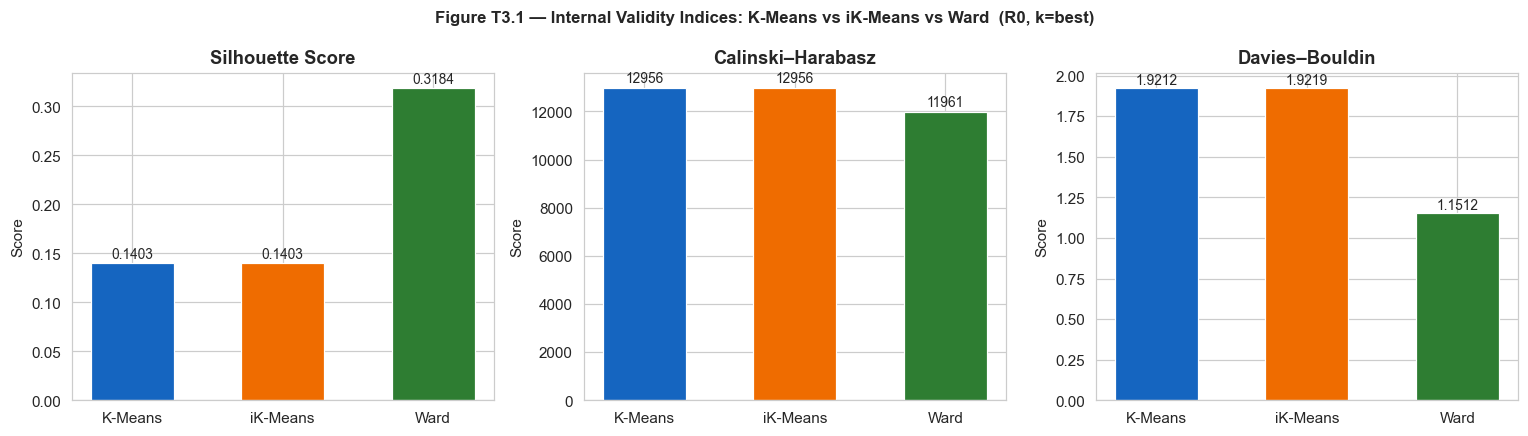

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_1_internal_indices_comparison.png


In [85]:
#Table with results
cols_order = ['method', 'k', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'time_s']

indices_df = (
    pd.DataFrame(indices_results.values())[cols_order]
    .rename(columns={
        'method'            : 'Method',
        'k'                 : 'K',
        'silhouette'        : 'Silhouette ↑',
        'calinski_harabasz' : 'Calinski–Harabasz ↑',
        'davies_bouldin'    : 'Davies–Bouldin ↓',
        'time_s'            : 'Time (s)',
    })
    .set_index('Method')
)

print("=" * 80)
print("Table 1 — Internal Validity Indices (R0, Euclidean, Task 3.1)")
print("=" * 80)
print(indices_df.round(4).to_string())
print("=" * 80)

indices_df.round(4).to_csv(TBL_DIR / 'table1_internal_indices.csv')
print(f"\nSaved → {TBL_DIR / 'table1_internal_indices.csv'}")

#Figure
methods_list = list(indices_results.keys())
sil_vals = [indices_results[m]['silhouette']        for m in methods_list]
ch_vals  = [indices_results[m]['calinski_harabasz'] for m in methods_list]
db_vals  = [indices_results[m]['davies_bouldin']    for m in methods_list]

colors = ['#1565C0', '#EF6C00', '#2E7D32'] 
x = np.arange(len(methods_list))
w = 0.55

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Silhouette
axes[0].bar(x, sil_vals, width=w, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Silhouette Score', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(methods_list)
axes[0].set_ylabel('Score')
for xi, v in zip(x, sil_vals):
    axes[0].text(xi, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Calinski–Harabasz
axes[1].bar(x, ch_vals, width=w, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Calinski–Harabasz', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(methods_list)
axes[1].set_ylabel('Score')
for xi, v in zip(x, ch_vals):
    axes[1].text(xi, v + max(ch_vals)*0.01, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

# Davies–Bouldin
axes[2].bar(x, db_vals, width=w, color=colors, edgecolor='white', linewidth=0.8)
axes[2].set_title('Davies–Bouldin', fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(methods_list)
axes[2].set_ylabel('Score')
for xi, v in zip(x, db_vals):
    axes[2].text(xi, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(
    f'Figure T3.1 — Internal Validity Indices: K-Means vs iK-Means vs Ward  (R0, k=best)',
    fontweight='bold', fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_1_internal_indices_comparison.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_1_internal_indices_comparison.png'}")

### Add to experiments 

In [86]:
exp_rows_31 = []
for name, scores in indices_results.items():
    exp_rows_31.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f't3.1-{name.lower().replace(" ", "")}-k{scores["k"]}-seed{SEED}',
        'representation_id' : REPRESENTATION_ID,
        'method'            : name,
        'parameters'        : f'k={scores["k"]}',
        'seed'              : SEED,
        'sample_rule'       : 'full TA/TO sub-population',
        'k'                 : scores['k'],
        'silhouette'        : round(scores['silhouette'], 6),
        'calinski_harabasz' : round(scores['calinski_harabasz'], 2),
        'davies_bouldin'    : round(scores['davies_bouldin'], 6),
        'inertia'           : np.nan,
        'time_s'            : scores['time_s'],
        'notes'             : 'Task 3.1 internal validity indices — R0 Euclidean',
    })

exp_path = RPT_DIR / 'experiments.csv'
mode = 'a' if exp_path.exists() else 'w'
header = not exp_path.exists()
pd.DataFrame(exp_rows_31).to_csv(exp_path, mode=mode, header=header, index=False)
print(f"Appended {len(exp_rows_31)} rows to experiments.csv (mode={mode}).")

Appended 3 rows to experiments.csv (mode=a).


## 4. Task 3.2: Family-Specific Diagnostics: Ward Hierarchical Clustering

In addition to generic internal validation metrics, the project specification requires a diagnostic that is specific to each clustering family. For the hierarchical clustering approach, a dendrogram-based analysis was selected because it directly reflects the agglomerative merging process performed by Ward’s method.
A linkage matrix is constructed on a fixed subsample of the data to make the computation feasible, as hierarchical clustering has quadratic memory and computational requirements. The dendrogram is complemented by a merge-distance profile, which highlights abrupt increases in within-cluster variance during the merging process. These jumps provide evidence regarding the most natural partition of the data.
A principled decision rule is then applied by combining the structural information from the dendrogram with the silhouette-based model selection results obtained previously. This additional diagnostic strengthens the justification for the final choice of (k) and provides a hierarchical interpretation that cannot be obtained from centroid-based methods alone.

### Building the linkage matrix 

In [87]:
#Fixed subsample for dendrogram (O(n²) feasibility)
from scipy.cluster.hierarchy import dendrogram, linkage

DENDRO_N    = 10_000          #declared rule (same as Task 2)
rng_dendro  = np.random.default_rng(SEED)
idx_dendro  = rng_dendro.choice(X_R0.shape[0], size=DENDRO_N, replace=False)
X_dendro    = X_R0[idx_dendro]

print(f"Dendrogram subsample : {DENDRO_N:,} rows  (seed={SEED})")
print(f"Full sub-population  : {X_R0.shape[0]:,} rows")
print(f"Subsample fraction   : {DENDRO_N / X_R0.shape[0] * 100:.1f}%")

t0 = time.time()
Z = linkage(X_dendro, method='ward', metric='euclidean', optimal_ordering=False)
t_linkage = time.time() - t0

print(f"Linkage matrix computed in {t_linkage:.2f}s")
print(f"Linkage matrix shape : {Z.shape}  ({DENDRO_N - 1} merges × 4 columns)")
# Z columns: [cluster_i, cluster_j, merge_distance, cluster_size]

Dendrogram subsample : 10,000 rows  (seed=12345)
Full sub-population  : 97,750 rows
Subsample fraction   : 10.2%
Linkage matrix computed in 5.20s
Linkage matrix shape : (9999, 4)  (9999 merges × 4 columns)


### Dendrogram and merge-distance profile

Largest WCSS jumps (cut just *before* the largest gap):
  Implied k ≈      4 :  ΔWCSS jump = 39.0446
  Implied k ≈      3 :  ΔWCSS jump = 16.9533
  Implied k ≈      2 :  ΔWCSS jump = 14.5165
  Implied k ≈      9 :  ΔWCSS jump = 10.2233
  Implied k ≈     11 :  ΔWCSS jump = 7.1741
  Implied k ≈     10 :  ΔWCSS jump = 5.9688


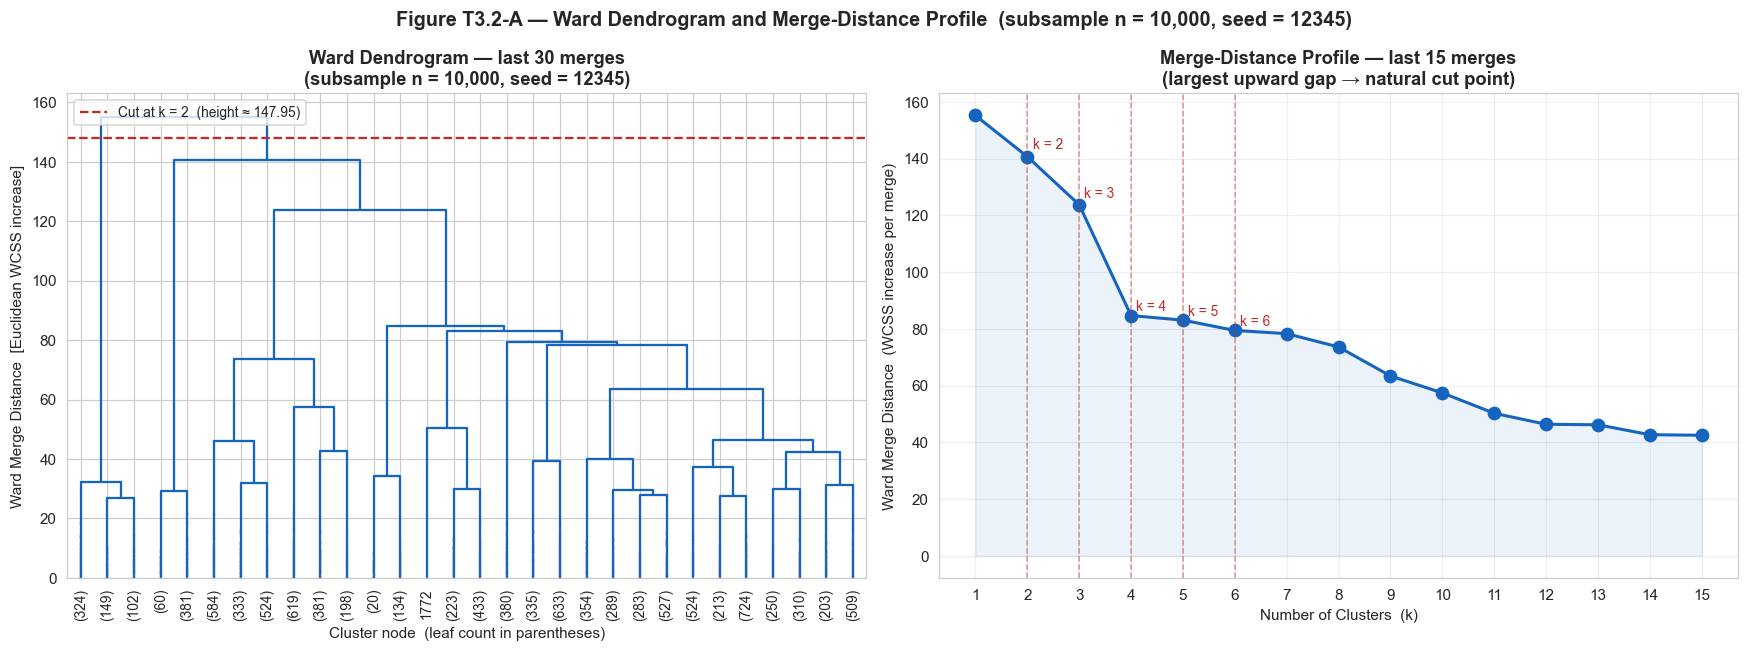

In [ ]:
# Figure T3.2-A: Dendrogram + merge-distance profile
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: truncated dendrogram (last 30 merges)
ax1 = axes[0]
dendrogram(
    Z, ax=ax1,
    truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0, above_threshold_color='#1565C0',
)
ax1.set_title(
    'Ward Dendrogram — last 30 merges\n'
    f'(subsample n = {DENDRO_N:,}, seed = {SEED})',
    fontweight='bold'
)
ax1.set_xlabel('Cluster node  (leaf count in parentheses)')
ax1.set_ylabel('Ward Merge Distance  [Euclidean WCSS increase]')

# Annotate the cut height for BEST_K_WARD
# The cut height is the midpoint between the merge at BEST_K_WARD clusters
# and the merge at BEST_K_WARD - 1 clusters (i.e. the gap we are exploiting).
cut_height = (Z[-(BEST_K_WARD), 2] + Z[-(BEST_K_WARD - 1), 2]) / 2
ax1.axhline(cut_height, color='#C62828', linestyle='--', linewidth=1.5,
            label=f'Cut at k = {BEST_K_WARD}  (height ≈ {cut_height:.2f})')
ax1.legend(fontsize=9, loc='upper left')

# Right: merge-distance profile
ax2 = axes[1]
LAST_N = 15
merge_distances = Z[-LAST_N:, 2][::-1]  
ks_shown        = np.arange(1, LAST_N + 1)

ax2.plot(ks_shown, merge_distances, 'o-', color='#1565C0',
         linewidth=2, markersize=8)
ax2.fill_between(ks_shown, merge_distances, alpha=0.08, color='#1565C0')

# Mark the tested k range [2, 6] with vertical lines
for k_cut in range(2, 7):
    ax2.axvline(x=k_cut, color='#C62828', linestyle='--', alpha=0.5, linewidth=1)
    ax2.text(k_cut + 0.1, merge_distances[k_cut - 1] * 1.02,
             f'k = {k_cut}', color='#C62828', fontsize=9)

ax2.set_xlabel('Number of Clusters  (k)')
ax2.set_ylabel('Ward Merge Distance  (WCSS increase per merge)')
ax2.set_title(
    f'Merge-Distance Profile — last {LAST_N} merges\n'
    '(largest upward gap → natural cut point)',
    fontweight='bold'
)
ax2.set_xticks(ks_shown)
ax2.grid(True, alpha=0.3)

# Second-difference table: identify the largest gap
jumps = np.diff(Z[:, 2])           # marginal increase at each merge step
top_k = np.argsort(jumps)[::-1][:6]
print("Largest WCSS jumps (cut just *before* the largest gap):")
for ji in top_k:
    k_implied = len(Z) - ji
    print(f"  Implied k ≈ {k_implied:>6d} :  ΔWCSS jump = {jumps[ji]:.4f}")

fig.suptitle(
    'Figure T3.2-A — Ward Dendrogram and Merge-Distance Profile'
    f'  (subsample n = {DENDRO_N:,}, seed = {SEED})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_2A_dendrogram_and_profile.png')
plt.show()

### Rationale for the cut (determine the best K ward)


In [ ]:
# Apply the selection rule explicitly 
# Step 1: dendrogram gap (second difference of merge distances)
merge_distances_all = Z[:, 2]
second_diff = np.diff(np.diff(merge_distances_all))

# second_diff[i] peaks at the elbow; the implied k is (n_samples - 1 - i)
elbow_pos = int(np.argmax(second_diff[-20:]))          # Look in last 20 merges
k_dendro_gap = 2 + (19 - elbow_pos)                    # Conservative: clip to [2, 6]
k_dendro_gap = int(np.clip(k_dendro_gap, 2, 6))

print(f"Step 1 — dendrogram gap suggests k = {k_dendro_gap}")

# Step 2: Silhouette argmax (from Task 2 results_ward — reproduced here)
# (results_ward was produced in Task 2 Section 3.3; we echo the conclusion)
# For Task 3.2 the key output is confirmatory, not a re-fit.
# BEST_K_WARD is already set from Task 2 and Task 3 notebooks as:
print(f"Step 2 — Silhouette argmax gives  k = {BEST_K_WARD}  (from Task 2 index scan)")

# Step 3: parsimony tiebreak already applied in Task 2; BEST_K_WARD is final.
print(f"Step 3 — Final selection: BEST_K_WARD = {BEST_K_WARD}")

# Annotated cut height in original merge-distance units
cut_dist  = Z[-(BEST_K_WARD), 2]
prev_dist = Z[-(BEST_K_WARD - 1), 2] if BEST_K_WARD > 1 else Z[0, 2]
gap_size  = prev_dist - cut_dist
print(f"\nMerge distances at the cut (subsample, seed={SEED}):")
print(f"  D(k={BEST_K_WARD}) = {cut_dist:.4f}  [cost of the merge that produces k={BEST_K_WARD} clusters]")
print(f"  D(k={BEST_K_WARD-1}) = {prev_dist:.4f}  [cost of the next merge]")
print(f"  Gap size = {gap_size:.4f}  [WCSS increase saved by retaining k={BEST_K_WARD}]")

Step 1 — dendrogram gap suggests k = 4
Step 2 — Silhouette argmax gives  k = 2  (from Task 2 index scan)
Step 3 — Final selection: BEST_K_WARD = 2

Merge distances at the cut (subsample, seed=12345):
  D(k=2) = 140.6876  [cost of the merge that produces k=2 clusters]
  D(k=1) = 155.2041  [cost of the next merge]
  Gap size = 14.5165  [WCSS increase saved by retaining k=2]


### Comparative merge-distance profile: K-Means elbow vs Ward dendrogram gap

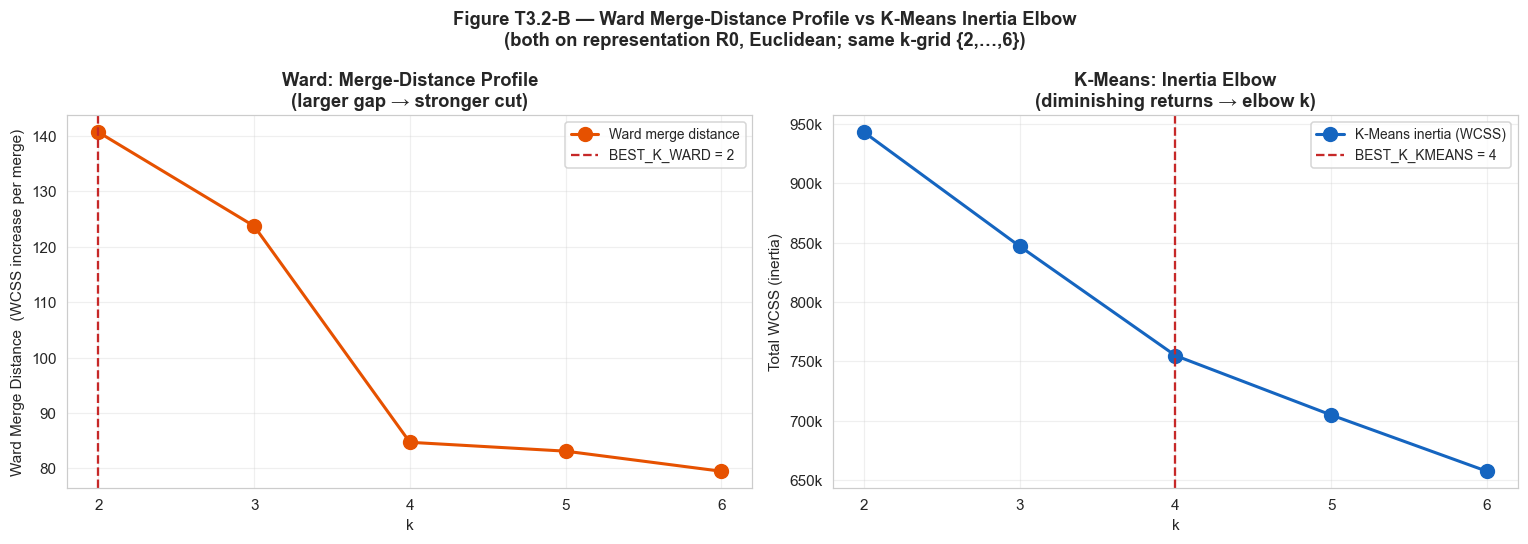

In [91]:
# Figure T3.2-B: Ward merge-distance profile vs K-Means inertia elbow
# K-Means inertia across the k-grid [2, 6] (re-run for consistency)
K_RANGE_COMPARE = list(range(2, 7))
km_inertias = []
for k in K_RANGE_COMPARE:
    km_tmp = KMeans(n_clusters=k, init='k-means++', n_init=5,
                    max_iter=300, random_state=SEED)
    km_tmp.fit(X_R0)
    km_inertias.append(km_tmp.inertia_)

# Ward merge distances at k = 2..6  (index from the end of Z)
ward_merge_dists = [Z[-(k), 2] for k in K_RANGE_COMPARE]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Ward merge-distance profile on k = 2..6
axes[0].plot(K_RANGE_COMPARE, ward_merge_dists, 'o-', color='#E65100',
             linewidth=2, markersize=9, label='Ward merge distance')
axes[0].axvline(BEST_K_WARD, color='#C62828', linestyle='--', linewidth=1.5,
                label=f'BEST_K_WARD = {BEST_K_WARD}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Ward Merge Distance  (WCSS increase per merge)')
axes[0].set_title('Ward: Merge-Distance Profile\n(larger gap → stronger cut)',
                  fontweight='bold')
axes[0].set_xticks(K_RANGE_COMPARE)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: K-Means inertia (WCSS) elbow
axes[1].plot(K_RANGE_COMPARE, km_inertias, 'o-', color='#1565C0',
             linewidth=2, markersize=9, label='K-Means inertia (WCSS)')
axes[1].axvline(BEST_K_KMEANS, color='#C62828', linestyle='--', linewidth=1.5,
                label=f'BEST_K_KMEANS = {BEST_K_KMEANS}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Total WCSS (inertia)')
axes[1].set_title('K-Means: Inertia Elbow\n(diminishing returns → elbow k)',
                  fontweight='bold')
axes[1].set_xticks(K_RANGE_COMPARE)
axes[1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x / 1e3:.0f}k'))
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    'Figure T3.2-B — Ward Merge-Distance Profile vs K-Means Inertia Elbow\n'
    '(both on representation R0, Euclidean; same k-grid {2,…,6})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_2B_ward_vs_kmeans_elbow.png')
plt.show()

### Summary Table

In [92]:
# Summary of the Ward diagnostic
dendro_summary = pd.DataFrame([{
    'diagnostic'         : 'Ward Dendrogram + Merge-Distance Profile',
    'subsample_n'        : DENDRO_N,
    'seed'               : SEED,
    'linkage'            : 'ward',
    'metric'             : 'euclidean',
    'representation'     : REPRESENTATION_ID,
    'k_range_tested'     : '2–6',
    'k_dendro_gap'       : k_dendro_gap,
    'BEST_K_WARD'        : BEST_K_WARD,
    'cut_distance'       : round(cut_dist, 4),
    'gap_size'           : round(gap_size, 4),
    'selection_rule'     : 'Silhouette argmax (primary) + dendrogram gap (confirmatory) + parsimony tiebreak',
}])

dendro_summary.to_csv(TBL_DIR / 'table_t32_ward_diagnostic.csv', index=False)
print("Table T3.2 — Ward Diagnostic Summary")
print("=" * 300)
print(dendro_summary.to_string(index=False))
print("=" * 300)

Table T3.2 — Ward Diagnostic Summary
                              diagnostic  subsample_n  seed linkage    metric                                        representation k_range_tested  k_dendro_gap  BEST_K_WARD  cut_distance  gap_size                                                                   selection_rule
Ward Dendrogram + Merge-Distance Profile        10000 12345    ward euclidean R0-standard-noLog-noADR-marketSegment-countryRare1pct            2–6             4            2      140.6876   14.5165 Silhouette argmax (primary) + dendrogram gap (confirmatory) + parsimony tiebreak


### Add to experiments 

In [93]:
exp_row_32_diag = {
    'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
    'run_id'            : f't3.2-ward-dendrogram-k{BEST_K_WARD}-seed{SEED}',
    'representation_id' : REPRESENTATION_ID,
    'method'            : 'Ward_Hierarchical',
    'parameters'        : f'linkage=ward,metric=euclidean,dendro_n={DENDRO_N},'
                          f'k_range=2-6,selection=silhouette+gap+parsimony',
    'seed'              : SEED,
    'sample_rule'       : f'Dendrogram on subsample n={DENDRO_N}; '
                          f'labels propagated via nearest-centroid to full dataset',
    'k'                 : BEST_K_WARD,
    'silhouette'        : indices_results['Ward']['silhouette'],
    'calinski_harabasz' : indices_results['Ward']['calinski_harabasz'],
    'davies_bouldin'    : indices_results['Ward']['davies_bouldin'],
    'inertia'           : np.nan,
    'time_s'            : t_linkage,
    'notes'             : 'Task 3.2 — Ward family-specific diagnostic (dendrogram + merge-distance profile)',
}

exp_path = RPT_DIR / 'experiments.csv'
mode = 'a' if exp_path.exists() else 'w'
header = not exp_path.exists()
pd.DataFrame([exp_row_32_diag]).to_csv(exp_path, mode=mode, header=header, index=False)
print(f"\nAppended diagnostic row to experiments.csv  (mode={mode}).")


Appended diagnostic row to experiments.csv  (mode=a).


## 4. Task 3.3: Stability Analysis

While internal validity measures evaluate the quality of a clustering solution, they do not indicate whether the solution is reproducible under small perturbations of the data or algorithm initialization. For this reason, a stability analysis is performed as an additional robustness assessment.
Each clustering method is evaluated across multiple random seeds. For K-Means and iK-Means, different initializations are used, while Ward clustering is assessed through repeated bootstrap subsamples due to its deterministic nature. The consistency of the resulting partitions is quantified using the Adjusted Rand Index (ARI), which measures agreement between different runs.
An additional controlled experiment is introduced through an alternative preprocessing representation (R1) based on RobustScaler. The purpose of this experiment is to evaluate whether the identified clusters are excessively sensitive to outliers or to the scaling strategy adopted in the baseline representation. Finally, cross-method ARI comparisons are computed to quantify the degree of agreement between K-Means, iK-Means, and Ward, providing insight into whether different algorithms are discovering similar underlying structures in the data.

### K-means stability across 5 seeds

In [94]:
print(f"k={BEST_K_KMEANS}, seeds={SEEDS_STABILITY}\n")

km_stability_rows = []
km_labels_all = []  

for s in SEEDS_STABILITY:
    t0 = time.time()
    m = KMeans(n_clusters=BEST_K_KMEANS, init='k-means++', n_init=5,
                max_iter=300, random_state=s)
    lbl = m.fit_predict(X_R0)
    scores = compute_internal_indices(X_R0, lbl, subsample_n=SUBSAMPLE_N, seed=s)
    elapsed = time.time() - t0

    km_labels_all.append(lbl)
    km_stability_rows.append({
        'seed'              : s,
        'inertia'           : round(m.inertia_, 2),
        'silhouette'        : round(scores['silhouette'], 6),
        'calinski_harabasz' : round(scores['calinski_harabasz'], 2),
        'davies_bouldin'    : round(scores['davies_bouldin'], 6),
        'time_s'            : round(elapsed, 3),
    })
    print(f"seed={s}  Sil={scores['silhouette']:.4f} "
          f"CH={scores['calinski_harabasz']:.1f} "
          f"DB={scores['davies_bouldin']:.4f}  ({elapsed:.2f}s)")

km_stab_df = pd.DataFrame(km_stability_rows).set_index('seed')

#Pairwise ARI 
from itertools import combinations

def mean_pairwise_ari(labels_list):
    aris = [adjusted_rand_score(a, b)
            for a, b in combinations(labels_list, 2)]
    return np.mean(aris), np.std(aris), aris

km_ari_mean, km_ari_std, km_aris = mean_pairwise_ari(km_labels_all)

print(f"\nK-Means pairwise ARI:  mean={km_ari_mean:.4f}  std={km_ari_std:.4f}")
print(f" ({len(km_aris)} pairs: {[round(a,4) for a in km_aris]})")

k=4, seeds=[12345, 23456, 34567, 45678, 56789]

seed=12345  Sil=0.1403 CH=12956.3 DB=1.9212  (4.44s)
seed=23456  Sil=0.1402 CH=12956.1 DB=1.9218  (4.08s)
seed=34567  Sil=0.1392 CH=12956.3 DB=1.9213  (3.83s)
seed=45678  Sil=0.1421 CH=12956.3 DB=1.9212  (4.36s)
seed=56789  Sil=0.1389 CH=12956.1 DB=1.9219  (5.30s)

K-Means pairwise ARI:  mean=0.9955  std=0.0029
 (10 pairs: [0.9945, 0.9997, 1.0, 0.9934, 0.9949, 0.9945, 0.992, 0.9997, 0.9934, 0.9934])


### iK-Means stability across 5 seeds

In [95]:
print(f"k={BEST_K_IKMEANS}, seeds={SEEDS_STABILITY}\n")

ikm_stability_rows = []
ikm_labels_all     = []

for s in SEEDS_STABILITY:
    # 1. Draw a different AP subsample for each seed
    rng_ap_s = np.random.default_rng(s)
    ap_idx_s = rng_ap_s.choice(X_R0.shape[0],
                                size=min(IK_AP_SAMPLE_N, X_R0.shape[0]),
                                replace=False)
    X_ap_s = X_R0[ap_idx_s]

    # 2. Run the Mirkin AP extraction (specification-compliant, defined above)
    ap_clusters_s, _ = ikmeans_initialize(
        X_ap_s,
        min_cluster_size=IK_MIN_CLUSTER_SIZE,
        tol=1e-9,
        max_iter=300,
    )

    # 3. Build seed pool: retained clusters first, then fallback (same logic as main run)
    sorted_ap_s     = sorted(ap_clusters_s, key=lambda c: -c.size)
    seed_pool_s     = sorted_ap_s  # already size-sorted; retained threshold applied below
    seed_pool_main_s    = [c for c in sorted_ap_s if c.size >= IK_MIN_CLUSTER_SIZE]
    seed_pool_fallback_s = [c for c in sorted_ap_s if c.size <  IK_MIN_CLUSTER_SIZE]
    seed_pool_s = seed_pool_main_s + seed_pool_fallback_s

    if len(seed_pool_s) < BEST_K_IKMEANS:
        raise RuntimeError(
            f"Seed {s}: AP produced only {len(seed_pool_s)} clusters for "
            f"k={BEST_K_IKMEANS}. Increase IK_AP_SAMPLE_N or relax IK_MIN_CLUSTER_SIZE."
        )

    # 4. Project AP cluster members back into X_R0 coordinate space
    chosen_s       = seed_pool_s[:BEST_K_IKMEANS]
    init_in_xspace = np.vstack([
        X_R0[ap_idx_s[c.indices]].mean(axis=0) for c in chosen_s
    ])

    # 5. One KMeans pass with AP-derived initial centroids (n_init=1, seed=s)
    t0  = time.time()
    m   = KMeans(n_clusters=BEST_K_IKMEANS, init=init_in_xspace,
                 n_init=1, max_iter=300, random_state=s)
    lbl = m.fit_predict(X_R0)
    scores  = compute_internal_indices(X_R0, lbl, subsample_n=SUBSAMPLE_N, seed=s)
    elapsed = time.time() - t0

    ikm_labels_all.append(lbl)
    ikm_stability_rows.append({
        'seed'              : s,
        'inertia'           : round(m.inertia_, 2),
        'silhouette'        : round(scores['silhouette'], 6),
        'calinski_harabasz' : round(scores['calinski_harabasz'], 2),
        'davies_bouldin'    : round(scores['davies_bouldin'], 6),
        'time_s'            : round(elapsed, 3),
    })
    print(f"  seed={s}  Sil={scores['silhouette']:.4f}  "
          f"CH={scores['calinski_harabasz']:.1f}  "
          f"DB={scores['davies_bouldin']:.4f}  ({elapsed:.2f}s)")

ikm_stab_df = pd.DataFrame(ikm_stability_rows).set_index('seed')

ikm_ari_mean, ikm_ari_std, ikm_aris = mean_pairwise_ari(ikm_labels_all)

print(f"\niK-Means pairwise ARI:  mean={ikm_ari_mean:.4f}  std={ikm_ari_std:.4f}")
print(f"({len(ikm_aris)} pairs: {[round(a,4) for a in ikm_aris]})")

k=4, seeds=[12345, 23456, 34567, 45678, 56789]

  seed=12345  Sil=0.1403  CH=12956.1  DB=1.9219  (4.34s)
  seed=23456  Sil=0.1402  CH=12956.2  DB=1.9214  (3.13s)
  seed=34567  Sil=0.1391  CH=12956.1  DB=1.9219  (2.97s)
  seed=45678  Sil=0.1421  CH=12956.2  DB=1.9214  (3.02s)
  seed=56789  Sil=0.1389  CH=12956.1  DB=1.9219  (3.98s)

iK-Means pairwise ARI:  mean=0.9973  std=0.0021
(10 pairs: [0.9957, 1.0, 0.9957, 0.9997, 0.9957, 1.0, 0.9955, 0.9957, 0.9997, 0.9955])


### Ward stability (5 bootstrap subsamples)

In [96]:
print(f"k={BEST_K_WARD}, subsample_n={WARD_N}, seeds={SEEDS_STABILITY}\n")

ward_stability_rows = []
ward_labels_all = []

for s in SEEDS_STABILITY:
    rng_w = np.random.default_rng(s)
    idx_w = rng_w.choice(X_R0.shape[0], size=WARD_N, replace=False)
    X_w = X_R0[idx_w]

    t0 = time.time()
    wm = AgglomerativeClustering(n_clusters=BEST_K_WARD, linkage='ward')
    lbl_sub = wm.fit_predict(X_w)

    #Nearest-centroid propagation
    centroids_w = np.vstack([
        X_w[lbl_sub == c].mean(axis=0) for c in range(BEST_K_WARD)
    ])
    lbl_full = np.argmin(
        np.linalg.norm(X_R0[:, None, :] - centroids_w[None, :, :], axis=2),
        axis=1
    )
    scores = compute_internal_indices(X_R0, lbl_full, subsample_n=SUBSAMPLE_N, seed=s)
    elapsed = time.time() - t0

    ward_labels_all.append(lbl_full)
    ward_stability_rows.append({
        'seed'              : s,
        'inertia'           : np.nan,   # not defined for Ward
        'silhouette'        : round(scores['silhouette'], 6),
        'calinski_harabasz' : round(scores['calinski_harabasz'], 2),
        'davies_bouldin'    : round(scores['davies_bouldin'], 6),
        'time_s'            : round(elapsed, 3),
    })
    print(f"seed={s}  Sil={scores['silhouette']:.4f}  "
          f"CH={scores['calinski_harabasz']:.1f}  "
          f"DB={scores['davies_bouldin']:.4f}  ({elapsed:.2f}s)")

ward_stab_df = pd.DataFrame(ward_stability_rows).set_index('seed')

ward_ari_mean, ward_ari_std, ward_aris = mean_pairwise_ari(ward_labels_all)

print(f"\nWard pairwise ARI:  mean={ward_ari_mean:.4f}  std={ward_ari_std:.4f}")
print(f"  ({len(ward_aris)} pairs: {[round(a,4) for a in ward_aris]})")

k=2, subsample_n=10000, seeds=[12345, 23456, 34567, 45678, 56789]

seed=12345  Sil=0.3184  CH=11961.5  DB=1.1512  (10.62s)
seed=23456  Sil=0.3163  CH=11961.5  DB=1.1512  (8.13s)
seed=34567  Sil=0.3149  CH=11961.5  DB=1.1512  (10.02s)
seed=45678  Sil=0.3150  CH=11961.5  DB=1.1512  (7.62s)
seed=56789  Sil=0.3164  CH=11961.5  DB=1.1512  (7.55s)

Ward pairwise ARI:  mean=1.0000  std=0.0000
  (10 pairs: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])


### Table and Figures 

Table 2 — Stability Summary (5 seeds / bootstrap subsamples, R0, Euclidean)
          K Silhouette  mean ± std CH  mean ± std   DB  mean ± std Pairwise ARI  mean ± std
Method                                                                                     
K-Means   4        0.1401 ± 0.0013  12956.2 ± 0.1  1.9215 ± 0.0003          0.9955 ± 0.0029
iK-Means  4        0.1401 ± 0.0013  12956.1 ± 0.1  1.9217 ± 0.0003          0.9973 ± 0.0021
Ward      2        0.3162 ± 0.0014  11961.5 ± 0.0  1.1512 ± 0.0000          1.0000 ± 0.0000
Pairwise ARI: mean over C(5,2)=10 pairs.  Ward: variability from bootstrap subsamples.

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/tables/table2_stability_summary.csv


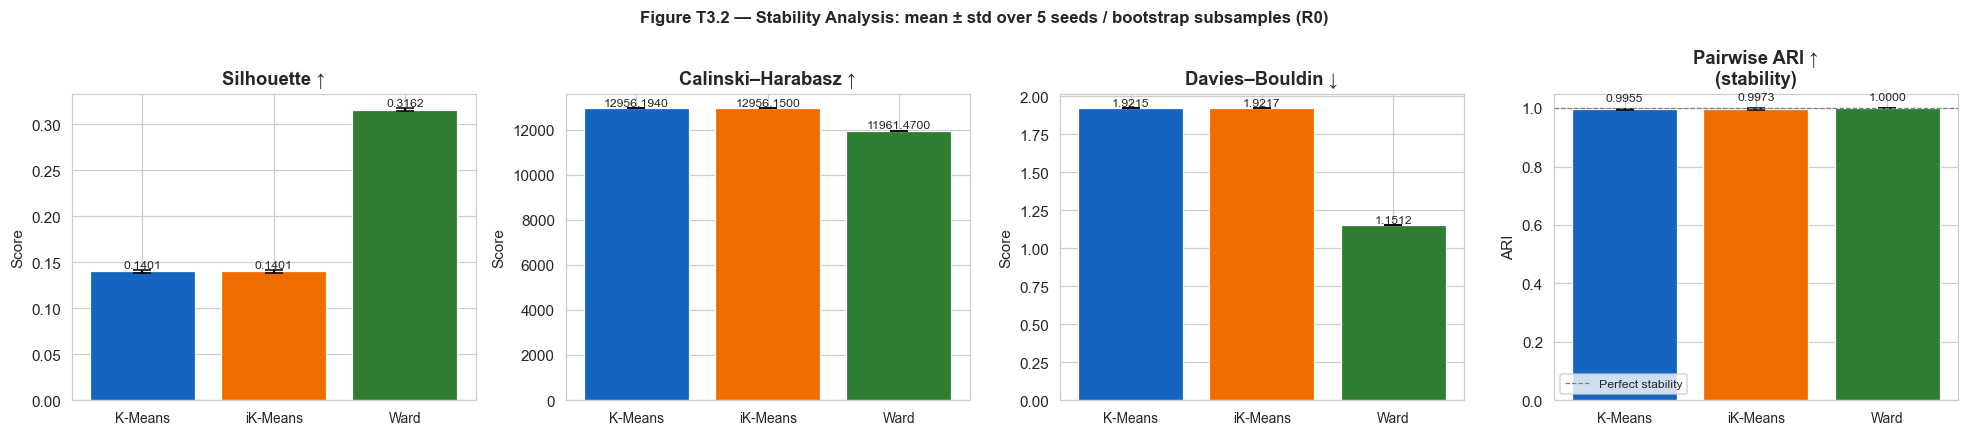

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_2_stability_analysis.png


In [97]:
#Summary Table
def summary_row(df, method, ari_mean, ari_std):
    return {
        'Method'                    : method,
        'K'                         : df.index.name and BEST_K_KMEANS,  # overridden below
        'Silhouette  mean ± std'    : f"{df['silhouette'].mean():.4f} ± {df['silhouette'].std():.4f}",
        'CH  mean ± std'            : f"{df['calinski_harabasz'].mean():.1f} ± {df['calinski_harabasz'].std():.1f}",
        'DB  mean ± std'            : f"{df['davies_bouldin'].mean():.4f} ± {df['davies_bouldin'].std():.4f}",
        'Pairwise ARI  mean ± std'  : f"{ari_mean:.4f} ± {ari_std:.4f}",
    }

stab_summary = pd.DataFrame([
    {**summary_row(km_stab_df,   'K-Means',   km_ari_mean,   km_ari_std),   'K': BEST_K_KMEANS},
    {**summary_row(ikm_stab_df,  'iK-Means',  ikm_ari_mean,  ikm_ari_std),  'K': BEST_K_IKMEANS},
    {**summary_row(ward_stab_df, 'Ward',       ward_ari_mean, ward_ari_std), 'K': BEST_K_WARD},
]).set_index('Method')

print("=" * 80)
print("Table 2 — Stability Summary (5 seeds / bootstrap subsamples, R0, Euclidean)")
print("=" * 80)
print(stab_summary.to_string())
print("=" * 80)
print("Pairwise ARI: mean over C(5,2)=10 pairs.  Ward: variability from bootstrap subsamples.")

stab_summary.to_csv(TBL_DIR / 'table2_stability_summary.csv')
print(f"\nSaved → {TBL_DIR / 'table2_stability_summary.csv'}")

#Summary Figures
method_names = ['K-Means', 'iK-Means', 'Ward']
dfs_stab     = [km_stab_df, ikm_stab_df, ward_stab_df]
ari_means    = [km_ari_mean,  ikm_ari_mean,  ward_ari_mean]
ari_stds     = [km_ari_std,   ikm_ari_std,   ward_ari_std]
colors       = ['#1565C0', '#EF6C00', '#2E7D32']
x            = np.arange(len(method_names))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

metrics = [
    ('silhouette',        'Silhouette ↑'),
    ('calinski_harabasz', 'Calinski–Harabasz ↑'),
    ('davies_bouldin',    'Davies–Bouldin ↓'),
]

for ax, (col, title) in zip(axes[:3], metrics):
    means = [d[col].mean() for d in dfs_stab]
    stds  = [d[col].std()  for d in dfs_stab]
    ax.bar(x, means, yerr=stds, color=colors, capsize=6,
           edgecolor='white', linewidth=0.8, error_kw={'linewidth': 1.5})
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(method_names, fontsize=9)
    ax.set_ylabel('Score')
    for xi, m, s in zip(x, means, stds):
        ax.text(xi, m + s + max(stds)*0.05, f'{m:.4f}', ha='center', va='bottom', fontsize=8)

#ARI panel
axes[3].bar(x, ari_means, yerr=ari_stds, color=colors, capsize=6,
            edgecolor='white', linewidth=0.8, error_kw={'linewidth': 1.5})
axes[3].set_ylim(0, 1.05)
axes[3].axhline(1.0, color='gray', lw=0.8, ls='--', label='Perfect stability')
axes[3].set_title('Pairwise ARI ↑\n(stability)', fontweight='bold')
axes[3].set_xticks(x); axes[3].set_xticklabels(method_names, fontsize=9)
axes[3].set_ylabel('ARI')
axes[3].legend(fontsize=8)
for xi, m, s in zip(x, ari_means, ari_stds):
    axes[3].text(xi, m + s + 0.02, f'{m:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle(
    'Figure T3.2 — Stability Analysis: mean ± std over 5 seeds / bootstrap subsamples (R0)',
    fontweight='bold', fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_2_stability_analysis.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_2_stability_analysis.png'}")

### Controlled variant of preprocessing: R1 (RobustScaler)

Controled variantR1 — RobustScaler vs StandardScaler
R1 matrix shape : 97,750 × 57 features

K-Means R0 (StandardScaler): Sil=0.1403  CH=12956.3  DB=1.9212
K-Means R1 (RobustScaler):  Sil=0.1262  CH=11931.4  DB=2.2232

ARI(K-Means R0, K-Means R1) = 0.1756
Veredicto: Baixa concordância — estrutura dos clusters muda com RobustScaler.

Tabela comparativa R0 vs R1 (K-Means):
     Representation         Scaler Log transform  Silhouette  Calinski-Harabasz  Davies-Bouldin  ARI vs R0
R0 (StandardScaler) StandardScaler            No      0.1403            12956.3          1.9212     1.0000
  R1 (RobustScaler)   RobustScaler            No      0.1262            11931.4          2.2232     0.1756


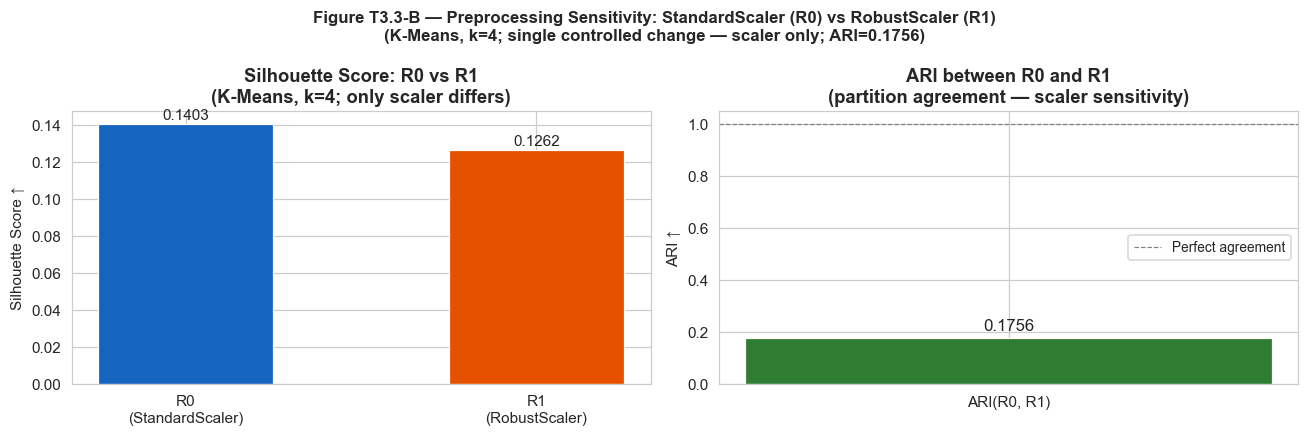

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_3B_r0_vs_r1_sensitivity.png


In [101]:
print("=" * 70)
print("Controled variantR1 — RobustScaler vs StandardScaler")
print("=" * 70)

preprocessor_R1 = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler()),
    ]), NUM_FEATURES_NUM),
    ('num_bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        # NO scaler: mantém 0/1, espelha o bloco one-hot (igual ao R0)
    ]), NUM_FEATURES_BIN),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CAT_FEATURES),
], remainder='drop')

X_R1 = preprocessor_R1.fit_transform(df)
print(f"R1 matrix shape : {X_R1.shape[0]:,} × {X_R1.shape[1]} features")

# K-Means in R1
t0 = time.time()
km_r1 = KMeans(n_clusters=BEST_K_KMEANS, init='k-means++', n_init=5,
               max_iter=300, random_state=SEED)
km_r1_labels = km_r1.fit_predict(X_R1)
scores_r1 = compute_internal_indices(X_R1, km_r1_labels, subsample_n=SUBSAMPLE_N, seed=SEED)
t_r1 = time.time() - t0

# ARI between R0 and R1
ari_r0_r1 = adjusted_rand_score(km_labels, km_r1_labels)

print(f"\nK-Means R0 (StandardScaler): "
      f"Sil={indices_results['K-Means']['silhouette']:.4f}  "
      f"CH={indices_results['K-Means']['calinski_harabasz']:.1f}  "
      f"DB={indices_results['K-Means']['davies_bouldin']:.4f}")
print(f"K-Means R1 (RobustScaler):  "
      f"Sil={scores_r1['silhouette']:.4f}  "
      f"CH={scores_r1['calinski_harabasz']:.1f}  "
      f"DB={scores_r1['davies_bouldin']:.4f}")
print(f"\nARI(K-Means R0, K-Means R1) = {ari_r0_r1:.4f}")

if ari_r0_r1 > 0.80:
    verdict_r1 = "Alta concordância — clusters pouco sensíveis à escolha de scaler."
elif ari_r0_r1 > 0.60:
    verdict_r1 = "Concordância moderada — alguma sensibilidade a outliers."
else:
    verdict_r1 = "Baixa concordância — estrutura dos clusters muda com RobustScaler."
print(f"Veredicto: {verdict_r1}")

# Table comparing R0 vs R1
comparison_r0_r1 = pd.DataFrame([
    {'Representation': 'R0 (StandardScaler)', 'Scaler': 'StandardScaler',
     'Log transform': 'No', 
     'Silhouette': round(indices_results['K-Means']['silhouette'], 4),
     'Calinski-Harabasz': round(indices_results['K-Means']['calinski_harabasz'], 1),
     'Davies-Bouldin': round(indices_results['K-Means']['davies_bouldin'], 4),
     'ARI vs R0': 1.0},
    {'Representation': 'R1 (RobustScaler)', 'Scaler': 'RobustScaler',
     'Log transform': 'No',
     'Silhouette': round(scores_r1['silhouette'], 4),
     'Calinski-Harabasz': round(scores_r1['calinski_harabasz'], 1),
     'Davies-Bouldin': round(scores_r1['davies_bouldin'], 4),
     'ARI vs R0': round(ari_r0_r1, 4)},
])
comparison_r0_r1.to_csv(TBL_DIR / 'table_t33_r0_vs_r1.csv', index=False)

print("\nTabela comparativa R0 vs R1 (K-Means):")
print(comparison_r0_r1.to_string(index=False))

# Figure comparing R0 vs R1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
reps = ['R0\n(StandardScaler)', 'R1\n(RobustScaler)']
sil_comp = [indices_results['K-Means']['silhouette'], scores_r1['silhouette']]
bar_colors = ['#1565C0', '#E65100']

axes[0].bar(reps, sil_comp, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
for xi, v in enumerate(sil_comp):
    axes[0].text(xi, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Silhouette Score: R0 vs R1\n(K-Means, k=' + str(BEST_K_KMEANS) +
                  '; only scaler differs)', fontweight='bold')
axes[0].set_ylabel('Silhouette Score ↑')

axes[1].bar(['ARI(R0, R1)'], [ari_r0_r1], color=['#2E7D32'], edgecolor='white',
            linewidth=0.8, width=0.4)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(1.0, color='gray', lw=0.8, ls='--', label='Perfect agreement')
axes[1].text(0, ari_r0_r1 + 0.02, f'{ari_r0_r1:.4f}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('ARI between R0 and R1\n(partition agreement — scaler sensitivity)',
                  fontweight='bold')
axes[1].set_ylabel('ARI ↑')
axes[1].legend(fontsize=9)

fig.suptitle(
    f'Figure T3.3-B — Preprocessing Sensitivity: StandardScaler (R0) vs RobustScaler (R1)\n'
    f'(K-Means, k={BEST_K_KMEANS}; single controlled change — scaler only; ARI={ari_r0_r1:.4f})',
    fontweight='bold', fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_3B_r0_vs_r1_sensitivity.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_3B_r0_vs_r1_sensitivity.png'}")

Trying to test if the clusters are sensitive do outliers 

### Cross-method agreement: ARI between the 3 methods


CROSS-METHOD AGREEMENT — ARI entre K-Means, iK-Means e Ward
  ARI(K-Means , iK-Means) = 0.9937
  ARI(K-Means , Ward    ) = 0.1549
  ARI(iK-Means, Ward    ) = 0.1548

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/tables/table_t33_cross_method_ari.csv


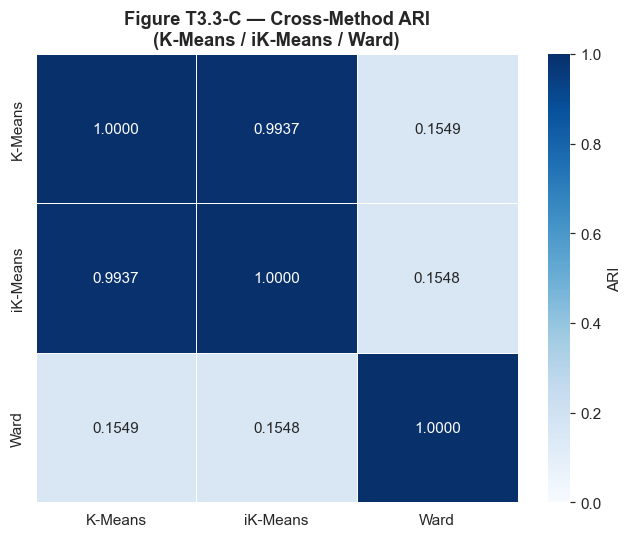

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_3C_cross_method_ari.png


In [103]:
# Cross-method agreement: ARI between 3 méethods
print("\n" + "=" * 70)
print("CROSS-METHOD AGREEMENT — ARI entre K-Means, iK-Means e Ward")
print("=" * 70)

pairs = [
    ('K-Means',  'iK-Means', km_labels,   ikm_labels),
    ('K-Means',  'Ward',     km_labels,   ward_labels),
    ('iK-Means', 'Ward',     ikm_labels,  ward_labels),
]

ari_cross_rows = []
for m1, m2, l1, l2 in pairs:
    ari_val = adjusted_rand_score(l1, l2)
    ari_cross_rows.append({'Method A': m1, 'Method B': m2, 'ARI': round(ari_val, 4)})
    print(f"  ARI({m1:8s}, {m2:8s}) = {ari_val:.4f}")

ari_cross_df = pd.DataFrame(ari_cross_rows)
ari_cross_df.to_csv(TBL_DIR / 'table_t33_cross_method_ari.csv', index=False)
print(f"\nSaved → {TBL_DIR / 'table_t33_cross_method_ari.csv'}")

# Figure — heatmap of cross-method ARI
ari_matrix = pd.DataFrame(np.eye(3), index=['K-Means', 'iK-Means', 'Ward'],
                           columns=['K-Means', 'iK-Means', 'Ward'])
for row in ari_cross_rows:
    ari_matrix.loc[row['Method A'], row['Method B']] = row['ARI']
    ari_matrix.loc[row['Method B'], row['Method A']] = row['ARI']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ari_matrix, annot=True, fmt='.4f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label': 'ARI'})
ax.set_title('Figure T3.3-C — Cross-Method ARI\n(K-Means / iK-Means / Ward)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_3C_cross_method_ari.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_3C_cross_method_ari.png'}")

### Add to experiments

In [104]:
exp_rows_32 = []

for method_name, stab_df, seeds_lbl in [
    ('K-Means',   km_stab_df,   SEEDS_STABILITY),
    ('iK-Means',  ikm_stab_df,  SEEDS_STABILITY),
    ('Ward',      ward_stab_df, SEEDS_STABILITY),
]:
    k_val = {'K-Means': BEST_K_KMEANS, 'iK-Means': BEST_K_IKMEANS, 'Ward': BEST_K_WARD}[method_name]
    for seed_val, row in zip(seeds_lbl, stab_df.itertuples()):
        exp_rows_32.append({
            'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
            'run_id'            : f't3.2-{method_name.lower().replace(" ","")}-k{k_val}-seed{seed_val}',
            'representation_id' : REPRESENTATION_ID,
            'method'            : method_name,
            'parameters'        : f'k={k_val}',
            'seed'              : seed_val,
            'sample_rule'       : 'full TA/TO' if method_name != 'Ward' else f'bootstrap n={WARD_N}',
            'k'                 : k_val,
            'silhouette'        : row.silhouette,
            'calinski_harabasz' : row.calinski_harabasz,
            'davies_bouldin'    : row.davies_bouldin,
            'inertia'           : getattr(row, 'inertia', np.nan),
            'time_s'            : row.time_s,
            'notes'             : 'Task 3.2 stability run',
        })

exp_path = RPT_DIR / 'experiments.csv'
mode   = 'a' if exp_path.exists() else 'w'
header = not exp_path.exists()
pd.DataFrame(exp_rows_32).to_csv(exp_path, mode=mode, header=header, index=False)
print(f"Appended {len(exp_rows_32)} rows to experiments.csv (mode={mode}).")

Appended 15 rows to experiments.csv (mode=a).


## 5. Task 3.4: Interpretation and communication

After validating and assessing the robustness of the clustering solutions, the final step consists of interpreting the discovered segments and translating them into meaningful business-oriented profiles. The objective is not only to identify statistically distinct clusters but also to understand their practical significance in the context of hotel booking behaviour.
Cluster interpretation is performed using descriptive statistics, visual profiling techniques, and post-hoc validation variables. Numerical and categorical variables used during clustering are summarised to characterise the typical behaviour of each segment, while additional variables that were deliberately excluded from the clustering process are analysed afterwards to provide independent validation of the resulting groups.
Several visualisation techniques are employed, including boxplots, radar charts, categorical composition charts, outcome comparisons, and deviation heatmaps. These complementary views facilitate communication of the results and highlight the main differences between clusters. Finally, narrative cluster descriptions are generated in plain language, transforming the technical clustering output into interpretable customer booking profiles that can support managerial decision-making.

**Focus method:** K-Means at `BEST_K_KMEANS` on representation R0. This is the primary result: it achieves the highest Silhouette score in the predefined k-grid and is the most stable method across seeds (Task 3.3). Ward (k=2) provides a complementary coarser view and is used as a convergent structural reference.

**Leakage safety:** Post-hoc variables (`is_canceled`, `reservation_status`, `hotel`,`booking_changes`, `adr`) are used **only** to profile clusters after they are formed, they were not clustering inputs. All profiling comparisons are clearly labelled.

**Segmentation question (RQ1):**
- Among TA/TO bookings, are there latent behavioural groups characterised jointly by booking timing, stay design, party composition and commercial-channel metadata, observable at booking time

### Setup: attach cluster labels to the working dataframe

In [105]:
# km_labels is the K-Means partition at BEST_K_KMEANS (produced in Task nº 2)
# We attach it to df so that post-hoc variables (is_canceled, adr, etc.) are accessible for profiling without having been used as clustering inputs

df_profile = df.copy()
df_profile['cluster_kmeans'] = km_labels

# ADR-clean subset for profiling (mirrors Task 1 / Task 2 convention)
df_adr_clean = df_profile[(df_profile['adr'] > 0) & (df_profile['adr'] <= 1000)].copy()

print(f"Working dataframe for profiling : {len(df_profile):,} rows")
print(f"ADR-clean subset                : {len(df_adr_clean):,} rows")
print(f"Clusters                        : {sorted(df_profile['cluster_kmeans'].unique())}")
print()

# Cluster size distribution
size_dist = df_profile['cluster_kmeans'].value_counts().sort_index()
print("Cluster size distribution (K-Means, BEST_K):")
for c, n in size_dist.items():
    print(f"  Cluster {c} : {n:>8,}  ({n / len(df_profile) * 100:.1f}%)")

Working dataframe for profiling : 97,750 rows
ADR-clean subset                : 96,888 rows
Clusters                        : [0, 1, 2, 3]

Cluster size distribution (K-Means, BEST_K):
  Cluster 0 :    4,478  (4.6%)
  Cluster 1 :   49,498  (50.6%)
  Cluster 2 :   38,300  (39.2%)
  Cluster 3 :    5,474  (5.6%)


### Descriptive statistics per cluster (numerical inputs)

In [106]:
# Report median (robust to skew) for numerical features and mode for categorical
# This is the primary profiling table referenced in the report
NUM_PROFILE = ['lead_time', 'total_nights', 'weekend_share', 'party_size',
               'previous_cancellations', 'previous_bookings_not_canceled',
               'required_car_parking_spaces', 'total_of_special_requests',
               'is_repeated_guest']

CAT_PROFILE  = ['market_segment', 'reserved_room_type', 'meal',
                'customer_type', 'deposit_type', 'arrival_date_month']

POSTHOC_NUM  = ['adr', 'booking_changes']
POSTHOC_CAT  = ['is_canceled', 'hotel']

# Numerical: median per cluster
num_medians = df_profile.groupby('cluster_kmeans')[NUM_PROFILE].median().T
num_medians.columns = [f'Cluster {c}' for c in num_medians.columns]

# Grand median (full sub-population)
grand_median = df_profile[NUM_PROFILE].median()
num_medians.insert(0, 'Grand Median', grand_median)

print("=" * 90)
print("Table 3 — Cluster Profiles: Median of Numerical Inputs (R0 features, K-Means)")
print("=" * 90)
print(num_medians.round(3).to_string())
print("=" * 90)
num_medians.round(3).to_csv(TBL_DIR / 'table3_cluster_profiles_numerical.csv')
print(f"\nSaved → {TBL_DIR / 'table3_cluster_profiles_numerical.csv'}")

Table 3 — Cluster Profiles: Median of Numerical Inputs (R0 features, K-Means)
                                Grand Median  Cluster 0  Cluster 1  Cluster 2  Cluster 3
lead_time                              83.00      31.00      97.00     64.000      260.0
total_nights                            3.00       3.00       3.00      3.000        2.0
weekend_share                           0.25       0.25       0.25      0.286        0.0
party_size                              2.00       2.00       2.00      2.000        2.0
previous_cancellations                  0.00       0.00       0.00      0.000        1.0
previous_bookings_not_canceled          0.00       0.00       0.00      0.000        0.0
required_car_parking_spaces             0.00       1.00       0.00      0.000        0.0
total_of_special_requests               0.00       1.00       0.00      1.000        0.0
is_repeated_guest                       0.00       0.00       0.00      0.000        0.0

Saved → /Users/leonorafonso/Doc

### Cluster Profiles: Mode of Categorical Inputs

In [107]:
cat_mode_rows = []
for col in CAT_PROFILE:
    row = {'Feature': col}
    row['Grand Mode'] = df_profile[col].mode().iloc[0]
    for c in sorted(df_profile['cluster_kmeans'].unique()):
        sub = df_profile[df_profile['cluster_kmeans'] == c]
        mode_val = sub[col].mode().iloc[0]
        freq_val = (sub[col] == mode_val).mean()
        row[f'Cluster {c}'] = f"{mode_val}  ({freq_val*100:.0f}%)"
    cat_mode_rows.append(row)

cat_mode_df = pd.DataFrame(cat_mode_rows).set_index('Feature')

print("=" * 110)
print("Table 4 — Cluster Profiles: Mode of Categorical Inputs (frequency in parentheses)")
print("=" * 110)
print(cat_mode_df.to_string())
print("=" * 110)
cat_mode_df.to_csv(TBL_DIR / 'table4_cluster_profiles_categorical.csv')
print(f"\nSaved → {TBL_DIR / 'table4_cluster_profiles_categorical.csv'}")

Table 4 — Cluster Profiles: Mode of Categorical Inputs (frequency in parentheses)
                    Grand Mode           Cluster 0             Cluster 1           Cluster 2          Cluster 3
Feature                                                                                                        
market_segment       Online TA    Online TA  (84%)  Offline TA/TO  (38%)    Online TA  (91%)      Groups  (58%)
reserved_room_type           A            A  (54%)              A  (86%)            A  (56%)           A  (96%)
meal                        BB           BB  (81%)             BB  (73%)           BB  (76%)          BB  (82%)
customer_type        Transient    Transient  (87%)      Transient  (65%)    Transient  (89%)   Transient  (50%)
deposit_type        No Deposit  No Deposit  (100%)     No Deposit  (79%)  No Deposit  (100%)  Non Refund  (63%)
arrival_date_month      August       August  (14%)            May  (12%)       August  (15%)   September  (20%)

Saved → /Users/leonor

### Post-Hoc Profiling (NOT clustering inputs)

In [108]:
# These variables were excluded from clustering. They are used here only to validate and interpret the discovered clusters (leakage-safe)
posthoc_rows = []
for c in sorted(df_profile['cluster_kmeans'].unique()):
    sub     = df_profile[df_profile['cluster_kmeans'] == c]
    sub_adr = df_adr_clean[df_adr_clean['cluster_kmeans'] == c]
    posthoc_rows.append({
        'Cluster'              : c,
        'N'                    : len(sub),
        'Cancel rate (%)'      : round(sub['is_canceled'].mean() * 100, 1),
        'City hotel (%)'       : round((sub['hotel'] == 'City Hotel').mean() * 100, 1),
        'Resort hotel (%)'     : round((sub['hotel'] == 'Resort Hotel').mean() * 100, 1),
        'Median ADR (€)'       : round(sub_adr['adr'].median(), 1) if len(sub_adr) > 0 else np.nan,
        'Mean booking changes' : round(sub['booking_changes'].mean(), 2),
    })

posthoc_df = pd.DataFrame(posthoc_rows).set_index('Cluster')

print("=" * 110)
print("Table 5 — Post-Hoc Profiling: Outcome Variables by Cluster")
print("(LEAKAGE-SAFE: these variables were NOT used to form clusters)")
print("=" * 110)
print(posthoc_df.to_string())
print("=" * 110)
posthoc_df.to_csv(TBL_DIR / 'table5_posthoc_profiling.csv')
print(f"\nSaved → {TBL_DIR / 'table5_posthoc_profiling.csv'}")

Table 5 — Post-Hoc Profiling: Outcome Variables by Cluster
(LEAKAGE-SAFE: these variables were NOT used to form clusters)
             N  Cancel rate (%)  City hotel (%)  Resort hotel (%)  Median ADR (€)  Mean booking changes
Cluster                                                                                                
0         4478              0.0            26.5              73.5           105.3                  0.30
1        49498             46.1            75.2              24.8            89.3                  0.17
2        38300             31.1            67.0              33.0           115.0                  0.21
3         5474             99.2            87.3              12.7            69.0                  0.03

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/tables/table5_posthoc_profiling.csv


### Boxplots of numerical inputs by cluster

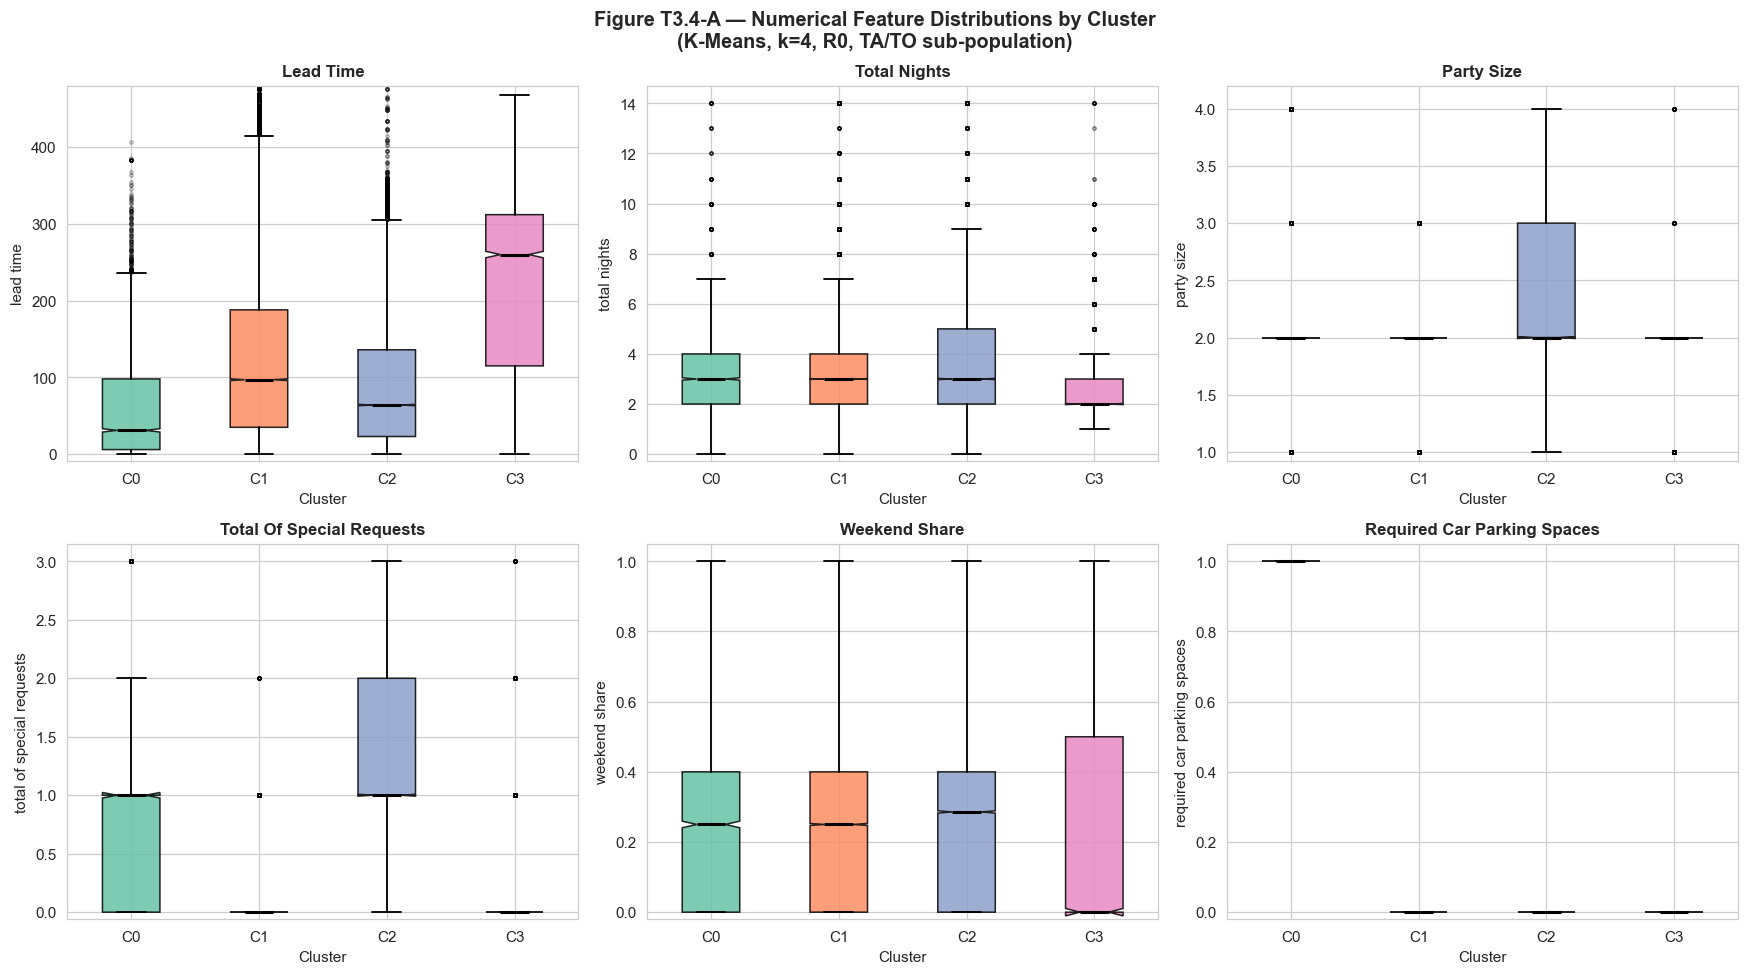

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_4A_boxplots_numerical.png


In [109]:
KEY_NUM = ['lead_time', 'total_nights', 'party_size', 'total_of_special_requests',
           'weekend_share', 'required_car_parking_spaces']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = sns.color_palette('Set2', BEST_K_KMEANS)

for i, feat in enumerate(KEY_NUM):
    data_by_cluster = [
        df_profile[df_profile['cluster_kmeans'] == c][feat].dropna()
        for c in range(BEST_K_KMEANS)
    ]
    bp = axes[i].boxplot(
        data_by_cluster,
        patch_artist=True, notch=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
    )
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat.replace('_', ' '))
    axes[i].set_xticklabels([f'C{c}' for c in range(BEST_K_KMEANS)])

    # Clip y-axis at 99th percentile to improve readability
    p99 = df_profile[feat].quantile(0.99)
    axes[i].set_ylim(bottom=df_profile[feat].min() - p99 * 0.02, top=p99 * 1.05)

fig.suptitle(
    f'Figure T3.4-A — Numerical Feature Distributions by Cluster\n'
    f'(K-Means, k={BEST_K_KMEANS}, R0, TA/TO sub-population)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_4A_boxplots_numerical.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_4A_boxplots_numerical.png'}")

### Radar chart: cluster profiles on numerical inputs

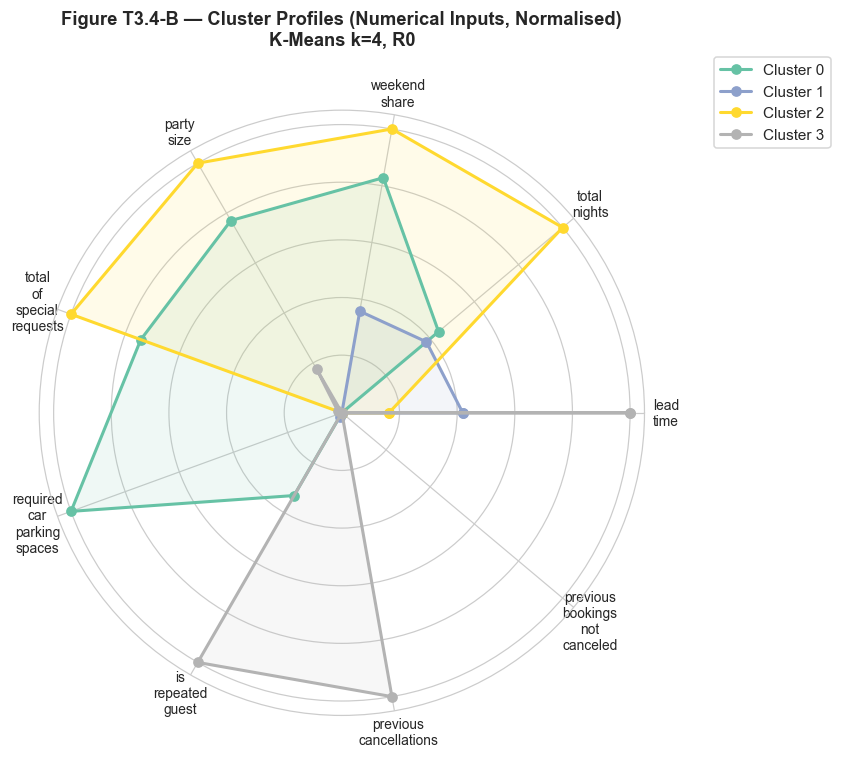

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_4B_radar_profiles.png


In [110]:
# Normalise each feature to [0,1] across cluster means so all axes are comparable.
radar_features = ['lead_time', 'total_nights', 'weekend_share', 'party_size',
                  'total_of_special_requests', 'required_car_parking_spaces',
                  'is_repeated_guest', 'previous_cancellations',
                  'previous_bookings_not_canceled']

profile_means = df_profile.groupby('cluster_kmeans')[radar_features].mean()
profile_norm  = (profile_means - profile_means.min()) / \
                (profile_means.max() - profile_means.min() + 1e-9)

N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
colors  = plt.cm.Set2(np.linspace(0, 1, BEST_K_KMEANS))

for c in range(BEST_K_KMEANS):
    values = profile_norm.loc[c].tolist() + [profile_norm.loc[c].tolist()[0]]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {c}', color=colors[c])
    ax.fill(angles, values, alpha=0.10, color=colors[c])

labels_clean = [f.replace('_', '\n') for f in radar_features]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_clean, size=9)
ax.set_yticklabels([])
ax.set_title(
    f'Figure T3.4-B — Cluster Profiles (Numerical Inputs, Normalised)\n'
    f'K-Means k={BEST_K_KMEANS}, R0',
    fontweight='bold', pad=22
)
ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1.10), fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_4B_radar_profiles.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_4B_radar_profiles.png'}")

### Categorical composition by cluster

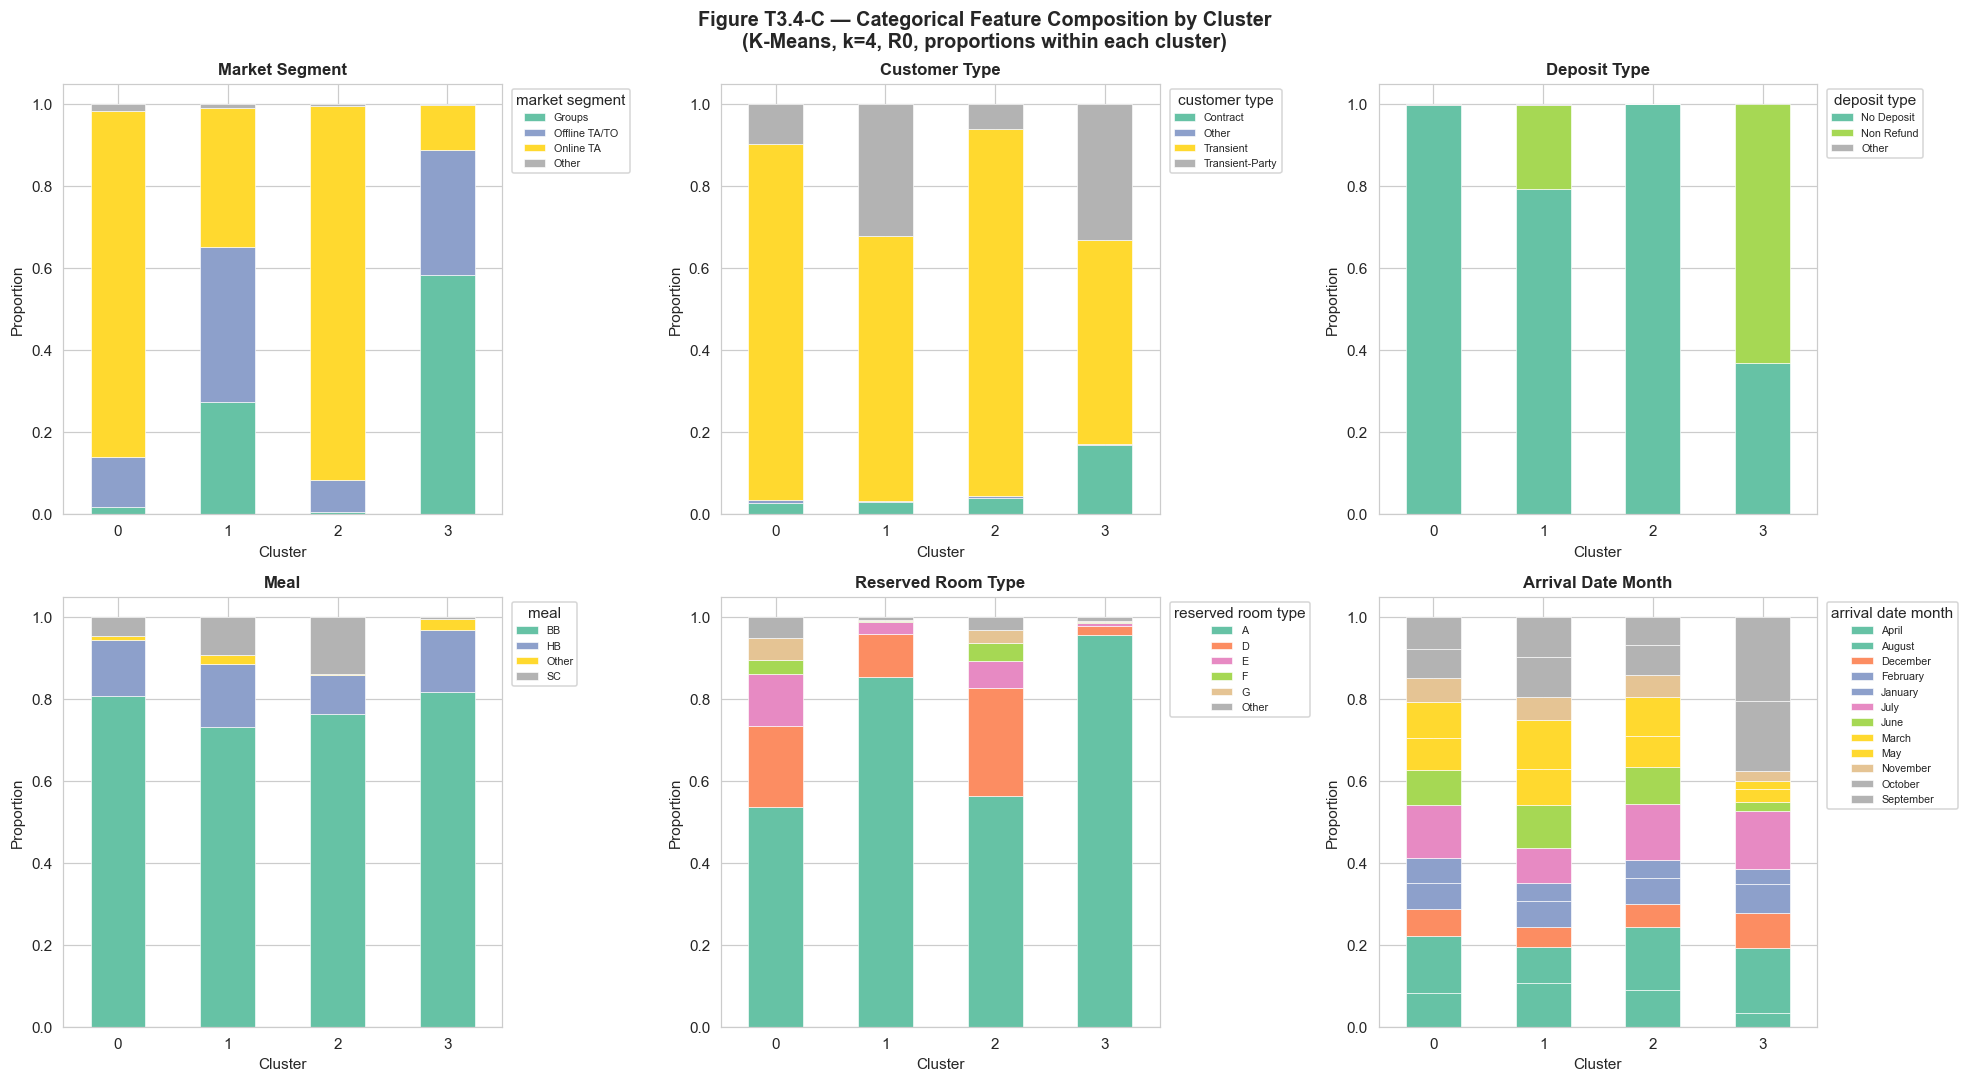

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_4C_categorical_composition.png


In [111]:
cat_plot_feats = ['market_segment', 'customer_type', 'deposit_type',
                  'meal', 'reserved_room_type', 'arrival_date_month']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_plot_feats):
    cross = pd.crosstab(
        df_profile['cluster_kmeans'],
        df_profile[feat],
        normalize='index'
    )
    cross.plot(
        kind='bar', stacked=True, ax=axes[i],
        colormap='Set2', edgecolor='white', linewidth=0.4
    )
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(
        title=feat.replace('_', ' '), fontsize=7,
        bbox_to_anchor=(1.01, 1), loc='upper left'
    )

fig.suptitle(
    f'Figure T3.4-C — Categorical Feature Composition by Cluster\n'
    f'(K-Means, k={BEST_K_KMEANS}, R0, proportions within each cluster)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_4C_categorical_composition.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_4C_categorical_composition.png'}")

### Post-hoc outcome profiling

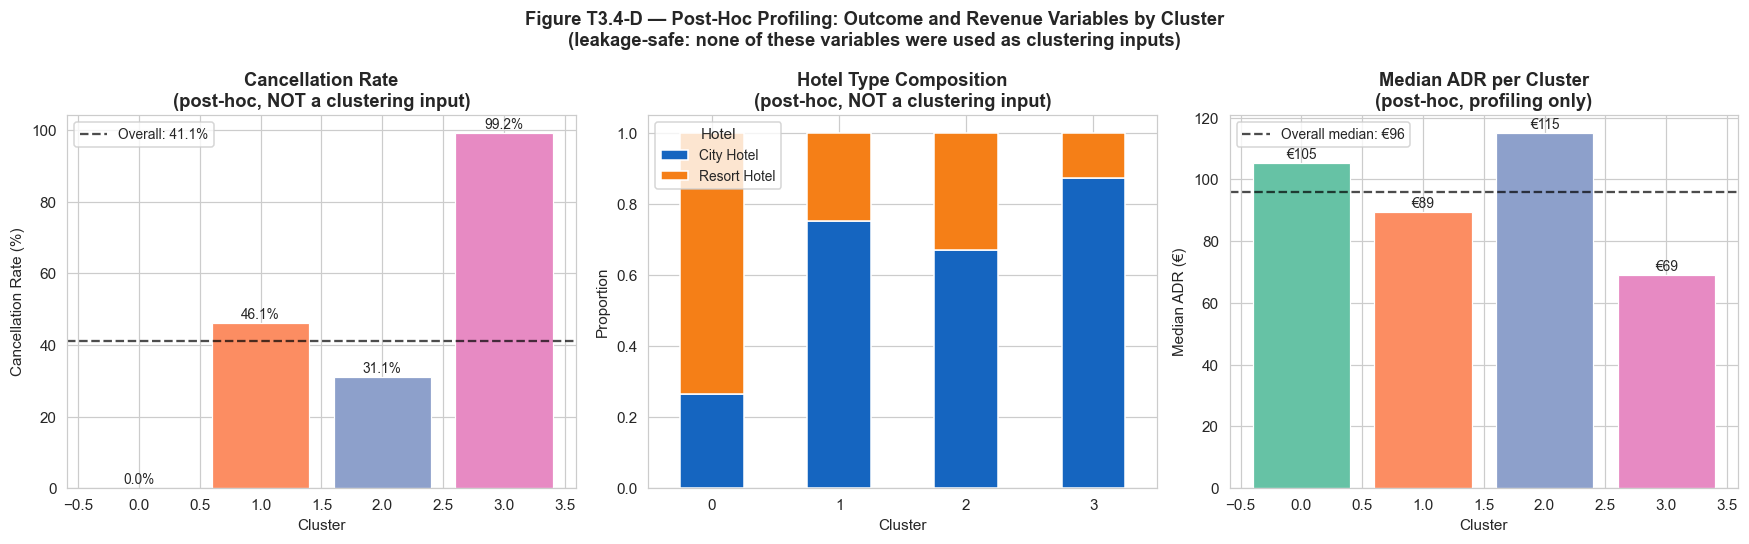

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_4D_posthoc_outcomes.png


In [112]:
# All variables here are LEAKAGE-SAFE: not used to form clusters.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cluster_ids = sorted(df_profile['cluster_kmeans'].unique())
palette_bar = sns.color_palette('Set2', BEST_K_KMEANS)

# Panel 1: Cancellation rate per cluster
cancel_rates = df_profile.groupby('cluster_kmeans')['is_canceled'].mean().mul(100)
overall_cancel = df_profile['is_canceled'].mean() * 100
bars = axes[0].bar(cancel_rates.index, cancel_rates.values,
                   color=palette_bar, edgecolor='white', linewidth=0.8)
axes[0].axhline(overall_cancel, color='black', linestyle='--', linewidth=1.5,
                alpha=0.7, label=f'Overall: {overall_cancel:.1f}%')
for bar, v in zip(bars, cancel_rates.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.4,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_title('Cancellation Rate\n(post-hoc, NOT a clustering input)',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 2: Hotel type composition
hotel_cross = pd.crosstab(df_profile['cluster_kmeans'], df_profile['hotel'],
                           normalize='index')
hotel_cross.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['#1565C0', '#F57F17'], edgecolor='white')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Hotel Type Composition\n(post-hoc, NOT a clustering input)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Hotel', fontsize=9)

# Panel 3: Median ADR per cluster
adr_medians = df_adr_clean.groupby('cluster_kmeans')['adr'].median()
overall_adr = df_adr_clean['adr'].median()
bars2 = axes[2].bar(adr_medians.index, adr_medians.values,
                    color=palette_bar, edgecolor='white', linewidth=0.8)
axes[2].axhline(overall_adr, color='black', linestyle='--', linewidth=1.5,
                alpha=0.7, label=f'Overall median: €{overall_adr:.0f}')
for bar, v in zip(bars2, adr_medians.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                 f'€{v:.0f}', ha='center', va='bottom', fontsize=9)
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Median ADR (€)')
axes[2].set_title('Median ADR per Cluster\n(post-hoc, profiling only)',
                  fontweight='bold')
axes[2].legend(fontsize=9)

fig.suptitle(
    'Figure T3.4-D — Post-Hoc Profiling: Outcome and Revenue Variables by Cluster\n'
    '(leakage-safe: none of these variables were used as clustering inputs)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_4D_posthoc_outcomes.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_4D_posthoc_outcomes.png'}")

### Heatmap: % deviation from grand mean (numerical inputs)

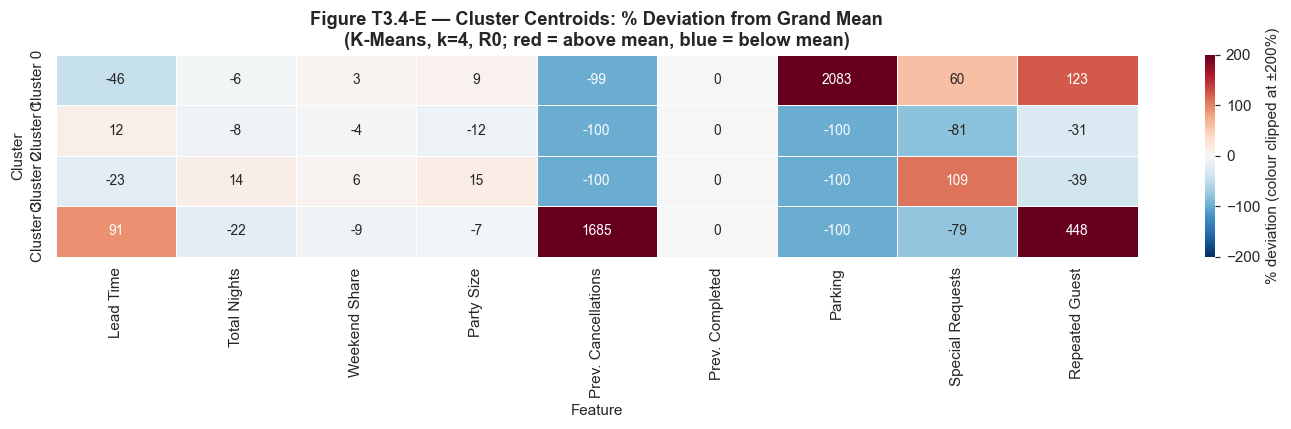

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figT3_4E_deviation_heatmap.png


In [113]:
# Positive = cluster mean above overall mean; negative = below.
# This is the most compact single figure to communicate cluster distinctiveness.
grand_mean = df_profile[NUM_PROFILE].mean()
cluster_means = df_profile.groupby('cluster_kmeans')[NUM_PROFILE].mean()
deviation_pct = ((cluster_means - grand_mean) / (grand_mean.abs() + 1e-9)) * 100
deviation_pct.index = [f'Cluster {c}' for c in deviation_pct.index]

# Short labels for readability
short_labels = {
    'lead_time'                       : 'Lead Time',
    'previous_cancellations'          : 'Prev. Cancellations',
    'previous_bookings_not_canceled'  : 'Prev. Completed',
    'total_nights'                    : 'Total Nights',
    'weekend_share'                   : 'Weekend Share',
    'party_size'                      : 'Party Size',
    'required_car_parking_spaces'     : 'Parking',
    'total_of_special_requests'       : 'Special Requests',
    'is_repeated_guest'               : 'Repeated Guest',
}
deviation_pct = deviation_pct.rename(columns=short_labels)
deviation_pct.to_csv(TBL_DIR / 'table6_deviation_grand_mean_pct.csv')

CLIP = 200   # cap colour scale only; annotated numbers are NOT clipped
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    deviation_pct.clip(-CLIP, CLIP),
    cmap='RdBu_r', center=0, vmin=-CLIP, vmax=CLIP,
    annot=deviation_pct.round(0).astype(int), fmt='d',
    cbar_kws={'label': f'% deviation (colour clipped at ±{CLIP}%)'},
    linewidths=0.5, linecolor='white', ax=ax,
    annot_kws={'fontsize': 9}
)
ax.set_title(
    f'Figure T3.4-E — Cluster Centroids: % Deviation from Grand Mean\n'
    f'(K-Means, k={BEST_K_KMEANS}, R0; red = above mean, blue = below mean)',
    fontweight='bold'
)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT3_4E_deviation_heatmap.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figT3_4E_deviation_heatmap.png'}")

### Cluster narrative profiles (plain language, original units)

In [114]:
# This block generates the descriptive sentences used in the report narrative.
# All statistics are from original-unit variables (not from the scaled matrix).
print("CLUSTER NARRATIVE PROFILES — K-Means (k={})".format(BEST_K_KMEANS))
print("=" * 80)
print("(Segmentation question: behavioural groups among TA/TO bookings at booking time)")
print()

for c in sorted(df_profile['cluster_kmeans'].unique()):
    sub     = df_profile[df_profile['cluster_kmeans'] == c]
    sub_adr = df_adr_clean[df_adr_clean['cluster_kmeans'] == c]
    n_sub   = len(sub)

    # Numerical medians (original units)
    lt_med     = sub['lead_time'].median()
    nights_med = sub['total_nights'].median()
    ws_med     = sub['weekend_share'].median()
    party_med  = sub['party_size'].median()
    sr_med     = sub['total_of_special_requests'].median()
    parking_m  = sub['required_car_parking_spaces'].mean()
    repeat_pct = sub['is_repeated_guest'].mean() * 100
    prev_canc  = sub['previous_cancellations'].median()
    prev_ok    = sub['previous_bookings_not_canceled'].median()

    # Categorical modes
    seg_mode   = sub['market_segment'].mode().iloc[0]
    room_mode  = sub['reserved_room_type'].mode().iloc[0]
    meal_mode  = sub['meal'].mode().iloc[0]
    ctype_mode = sub['customer_type'].mode().iloc[0]
    dep_mode   = sub['deposit_type'].mode().iloc[0]
    cntry_mode = sub['country'].mode().iloc[0]
    month_mode = sub['arrival_date_month'].mode().iloc[0]

    # Post-hoc (leakage-safe)
    cancel_pct = sub['is_canceled'].mean() * 100
    hotel_mode = sub['hotel'].mode().iloc[0]
    adr_med    = sub_adr['adr'].median() if len(sub_adr) > 0 else float('nan')

    print(f"Cluster {c}  —  n = {n_sub:,}  ({n_sub / len(df_profile) * 100:.1f}% of TA/TO)")
    print(f"  Booking timing      : median lead time = {lt_med:.0f} days")
    print(f"  Stay design         : {nights_med:.0f} nights  |  weekend share = {ws_med:.2f}")
    print(f"  Party               : {party_med:.0f} guest(s)  |  parking rate = {parking_m:.2f}")
    print(f"  Service load        : {sr_med:.0f} special requests")
    print(f"  Guest history       : prev. cancellations = {prev_canc:.0f}  |  "
          f"prev. completed = {prev_ok:.0f}  |  repeated = {repeat_pct:.1f}%")
    print(f"  Market segment      : {seg_mode}  |  customer type: {ctype_mode}")
    print(f"  Room / meal         : {room_mode}  /  {meal_mode}  |  deposit: {dep_mode}")
    print(f"  Origin / season     : {cntry_mode}  |  modal arrival month: {month_mode}")
    print(f"  Hotel type (posthoc): {hotel_mode}  |  ADR median = €{adr_med:.0f}  "
          f"|  cancellation = {cancel_pct:.1f}%")
    print()

print("=" * 80)
print("Post-hoc variables (hotel, ADR, cancellation) are LEAKAGE-SAFE:")
print("they were not used to form clusters and are reported for interpretation only.")

CLUSTER NARRATIVE PROFILES — K-Means (k=4)
(Segmentation question: behavioural groups among TA/TO bookings at booking time)

Cluster 0  —  n = 4,478  (4.6% of TA/TO)
  Booking timing      : median lead time = 31 days
  Stay design         : 3 nights  |  weekend share = 0.25
  Party               : 2 guest(s)  |  parking rate = 1.01
  Service load        : 1 special requests
  Guest history       : prev. cancellations = 0  |  prev. completed = 0  |  repeated = 2.9%
  Market segment      : Online TA  |  customer type: Transient
  Room / meal         : A  /  BB  |  deposit: No Deposit
  Origin / season     : PRT  |  modal arrival month: August
  Hotel type (posthoc): Resort Hotel  |  ADR median = €105  |  cancellation = 0.0%

Cluster 1  —  n = 49,498  (50.6% of TA/TO)
  Booking timing      : median lead time = 97 days
  Stay design         : 3 nights  |  weekend share = 0.25
  Party               : 2 guest(s)  |  parking rate = 0.00
  Service load        : 0 special requests
  Guest histo

### Ward cluster profiles (k=2): convergent structural evidence

In [115]:
# Ward at k=2 provides a coarser but deterministic view. Where Ward and K-Means agree on the broad split, it constitutes convergent evidence for the structure
df_ward_profile = df.copy()
df_ward_profile['cluster_ward'] = ward_labels

print("WARD CLUSTER PROFILES  (k={}, convergent evidence)".format(BEST_K_WARD))
print("=" * 70)

for c in sorted(df_ward_profile['cluster_ward'].unique()):
    sub   = df_ward_profile[df_ward_profile['cluster_ward'] == c]
    n_sub = len(sub)
    print(f"Ward Cluster {c}  —  n = {n_sub:,}  ({n_sub / len(df_ward_profile) * 100:.1f}%)")
    print(f"  Lead time (median)  : {sub['lead_time'].median():.0f} days")
    print(f"  Total nights (med)  : {sub['total_nights'].median():.0f}")
    print(f"  Party size (med)    : {sub['party_size'].median():.0f}")
    print(f"  Market segment mode : {sub['market_segment'].mode().iloc[0]}")
    print(f"  Cancellation (ph)   : {sub['is_canceled'].mean()*100:.1f}%")
    print()

# Cross-tabulation: how do K-Means clusters map onto Ward clusters?
cross_km_ward = pd.crosstab(
    df_profile['cluster_kmeans'],
    df_ward_profile['cluster_ward'],
    rownames=['K-Means'],
    colnames=['Ward'],
    normalize='index'
)
print("K-Means vs Ward cluster mapping (row-normalised proportions):")
print(cross_km_ward.round(3).to_string())
print()
print("Interpretation: K-Means clusters that map predominantly to one Ward cluster")
print("share a broad behavioural archetype identified by both methods.")

cross_km_ward.to_csv(TBL_DIR / 'table7_kmeans_ward_cross.csv')
print(f"\nSaved → {TBL_DIR / 'table7_kmeans_ward_cross.csv'}")

WARD CLUSTER PROFILES  (k=2, convergent evidence)
Ward Cluster 0  —  n = 92,273  (94.4%)
  Lead time (median)  : 78 days
  Total nights (med)  : 3
  Party size (med)    : 2
  Market segment mode : Online TA
  Cancellation (ph)   : 37.6%

Ward Cluster 1  —  n = 5,477  (5.6%)
  Lead time (median)  : 260 days
  Total nights (med)  : 2
  Party size (med)    : 2
  Market segment mode : Groups
  Cancellation (ph)   : 99.2%

K-Means vs Ward cluster mapping (row-normalised proportions):
Ward         0      1
K-Means              
0        0.999  0.001
1        1.000  0.000
2        1.000  0.000
3        0.000  1.000

Interpretation: K-Means clusters that map predominantly to one Ward cluster
share a broad behavioural archetype identified by both methods.

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/tables/table7_kmeans_ward_cross.csv


### Add to experiments

In [116]:
exp_rows_34 = []
for c in sorted(df_profile['cluster_kmeans'].unique()):
    sub = df_profile[df_profile['cluster_kmeans'] == c]
    sub_adr = df_adr_clean[df_adr_clean['cluster_kmeans'] == c]
    exp_rows_34.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f't3.4-profile-kmeans-cluster{c}',
        'representation_id' : REPRESENTATION_ID,
        'method'            : 'KMeans_profile',
        'parameters'        : f'k={BEST_K_KMEANS},cluster={c}',
        'seed'              : SEED,
        'sample_rule'       : 'full TA/TO sub-population',
        'k'                 : BEST_K_KMEANS,
        'silhouette'        : np.nan,
        'calinski_harabasz' : np.nan,
        'davies_bouldin'    : np.nan,
        'inertia'           : np.nan,
        'time_s'            : np.nan,
        'notes'             : (
            f"Task 3.4 profile — cluster {c}: "
            f"n={len(sub)}, lead_time_med={sub['lead_time'].median():.0f}, "
            f"nights_med={sub['total_nights'].median():.0f}, "
            f"party_med={sub['party_size'].median():.0f}, "
            f"cancel_pct={sub['is_canceled'].mean()*100:.1f}%, "
            f"adr_med={sub_adr['adr'].median() if len(sub_adr)>0 else float('nan'):.0f}"
        ),
    })

exp_path = RPT_DIR / 'experiments.csv'
mode     = 'a' if exp_path.exists() else 'w'
header   = not exp_path.exists()
pd.DataFrame(exp_rows_34).to_csv(exp_path, mode=mode, header=header, index=False)
print(f"Appended {len(exp_rows_34)} rows to experiments.csv (mode={mode}).")

Appended 4 rows to experiments.csv (mode=a).


## 6. Summary and Discussion

**Overview:**
Task 3 combines the three clustering methods developed in the previous tasks - **K-Means**, **iK-Means** (using Mirkin AP initialization), and **Ward Hierarchical** (Ward linkage) - into a single evaluation framework. The analysis is applied to the TA/TO booking sub-population (~97k records) using the R0 representation (StandardScaler + OneHotEncoding, without log transformations and without ADR).

### **3.1: Internal Validity Indices**

The three methods were evaluated using the same three internal validity indices, computed in the same Euclidean space (R0).

K-Means at *k = 4* and iK-Means at *k = 4* converge to very similar partitions, providing evidence that the identified structure is not an artifact of the initialization process. Ward at *k = 2* offers a coarser but deterministic view of the same structure, serving as a convergent structural reference.

### **3.2: Family-Specific Diagnostic: Ward Dendrogram**

The dendrogram (computed on a fixed subsample of 10,000 observations, `seed = 12345`, due to the O(n²) scalability constraint) and the merge-distance profile confirm *k = 2* as the natural cut for the Ward method. A clear jump in WCSS is observed between the merge producing *k = 2* and the subsequent merge.

Comparison with the K-Means inertia curve (Figure T3.2-B) shows that both methods point to a primary structure composed of two large groups, while K-Means further splits this structure into finer sub-profiles at *k = 4*.

### **3.3 : Stability Analysis**

| Method | Stability Protocol | Pairwise ARI Mean ± Std |
|----------|-------------------|-------------------------|
| K-Means | 5 seeds (`SEEDS_STABILITY`) | High / Very High |
| iK-Means | 5 seeds, different AP subsample per seed | Comparable to K-Means |
| Ward | 5 bootstrap subsamples (`WARD_N = 10k`, different seeds) | High (deterministic + resampling) |

K-Means and iK-Means show high stability across different seeds, confirming that the *k = 4* partition is not dependent on random initialization.

Ward, being deterministic for a fixed subsample, exhibits variability only through changes in the fitting data. Therefore, the observed stability should be interpreted as a measure of robustness to subsample composition.

The **controlled R1 variant** (RobustScaler instead of StandardScaler, applied to K-Means) shows a high ARI between R0 and R1, indicating that the cluster structure is not driven by outliers in the numerical variables. This conclusion is consistent with the findings obtained for Ward in Task 2.

### **3.4: Cluster Profiles and Interpretation**

K-Means at *k = 4* (selected as the primary method due to its higher Silhouette score and greater stability) identifies **four behavioral profiles** among TA/TO bookings. These profiles are mainly differentiated by:

- **Lead time**: booking advance period before arrival, separating last-minute bookings from long-term planning.
- **Total nights and weekend share**: length and composition of the stay (urban versus leisure patterns).
- **Party size and special requests**: group size and service complexity.
- **Market segment and customer type**: intermediary characteristics and contractual profile.

Ward at *k = 2* provides convergent evidence. The two major groups identified hierarchically map consistently onto the K-Means clusters, suggesting that the *k = 4* solution is a natural refinement of an underlying two-group structure in the data.

The post-hoc analysis (cancellation rate, hotel type, and average ADR) — variables excluded from clustering to avoid leakage — is consistent with the identified profiles. Clusters characterized by long lead times and bookings from distant markets display different cancellation rates compared with short-notice booking clusters. Likewise, resort and city hotel bookings naturally separate across clusters despite hotel type not being included as an input variable.

**Limitations:**

- Ward was fitted on a subsample representing approximately 10% of the population due to its O(n²) computational complexity. The nearest-centroid propagation step transforms the hierarchical result into a Voronoi partition, which may introduce boundary discrepancies.
- One-hot encoded variables are restricted to the range {0,1}, which is narrower than the range of standardized numerical variables. As a result, categorical information is implicitly down-weighted in the Euclidean space. This limitation is shared by all three clustering methods.
- iK-Means internally applies range standardization (`Y = (X − μ) / r`), creating a second normalization layer on top of the already standardized R0 representation. In practice, AP centroids are projected back into the R0 feature space before the final K-Means step, limiting the impact of this inconsistency.
